# Imports and Utils

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

In [3]:
os.chdir("/accounts/projects/jchayes/commnotes/analysis")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from scipy.stats import spearmanr
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess as _lowess
from scipy.stats import fisher_exact

from linearmodels.panel import PanelOLS

from src.data_loader import *
from src.analysis import *
from src.visualization import *
from src.visualization import (
    _C_BLUE, _C_ORANGE, _C_EVENT, _C_ZERO, _C_LIGHT, _C_PURPLE, _C_AMBER,
    _MUTED_PALETTE,
    _FONT_LEGEND, _FONT_LABEL, _FONT_TITLE, _FONT_TICK, _FONT_ANNOT,
    _setup_ax, _finalize, apply_publication_style,
)
from src.utils import *

apply_publication_style()

In [5]:
# --- Configuration (Corrected Paths) ---
# Using the absolute paths from your working environment
NOTES_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/notes-00000.tsv"
HISTORY_PATH = "/scratch/users/commnotes/communitynotes/sourcecode/noteStatusHistory-00000.tsv"
RATINGS_DIR = "/scratch/users/commnotes/communitynotes/sourcecode/ratings"
WEEKLY_OUTPUTS_PATH = "/scratch/users/commnotes/communitynotes2022/communitynotes/static/sourcecode/weekly_outputs"
WEEKLY_OUTPUTS_PATH_2025 = "/scratch/users/commnotes/communitynotes/sourcecode/weekly_outputs"


max_date = "2023-06-01"

In [6]:
print("--- Loading and Preparing Data ---")
# This DataFrame contains data related to "notes" associated with tweets. It includes unique IDs for notes, authors, and tweets, along with
# timestamps, classifications (e.g., "MISINFORMED_OR_POTENTIALLY_MISLEADING"), and other
# attributes describing the history of the notes
notes_df = pd.read_csv(NOTES_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})
notes_df["noteId"]=notes_df["noteId"].astype(int)

# The following is all note ratings published by X
# I only kept the following columns "'noteId', 'raterParticipantId', 'createdAtMillis', 'helpfulnessLevel'" since we don't use the rest.
ratings_df = read_ratings_from_directory(RATINGS_DIR, start_date_str="2022-06-01",end_date_str=max_date)

# The following df is the results of the matrix factorzation 
note_df_full, rater_df, status_df, helpfulness_df, aux_df = load_weekly_outputs(WEEKLY_OUTPUTS_PATH,debug=False)
note_df_full_2025, rater_df_2025, status_df_2025, helpfulness_df_2025, aux_df_2025 = load_weekly_outputs(WEEKLY_OUTPUTS_PATH_2025,debug=False)

history_df =   pd.read_csv(HISTORY_PATH, sep='\\t', dtype={'noteAuthorParticipantId': str, 'tweetId': str, 'noteId': str})

# The following df is notes with corresponding topics. Topics are modelled by the X topic modeling algorithm.
notes_df_topic = pd.read_csv("/accounts/projects/jchayes/commnotes/df_notes_with_topics.csv")
notes_df_topic['noteId'] = notes_df_topic['noteId'].astype(int)

--- Loading and Preparing Data ---


/tmp/ipykernel_1324750/1752173335.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


Found 16 total rating files. Processing them in chunks to filter by date.


Loading weekly outputs: 100%|██████████| 84/84 [02:09<00:00,  1.54s/it]


note is loaded.
rater is loaded.
status is loaded.
helpfulness is loaded.
aux is loaded.


Loading weekly outputs: 100%|██████████| 44/44 [00:03<00:00, 13.91it/s]
/tmp/ipykernel_1324750/1752173335.py:16: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


note is loaded.
rater is loaded.
status is loaded.
key without data status
helpfulness is loaded.
key without data helpfulness
aux is loaded.
key without data aux


In [7]:
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms')

In [8]:
rater_df_2025 = rater_df_2025.rename(columns={"internalRaterFactor1": "raterFactor1", "internalRaterIntercept": "raterIntercept"})
note_df_full_2025 = note_df_full_2025.rename(columns={"internalNoteFactor1": "noteFactor1", "internalNoteIntercept": "noteIntercept"})

In [9]:
rollout_date = pd.to_datetime("2022-10-01")

In [10]:
# Ensure datetime
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtDate'])
first_rating = ratings_df.groupby('raterParticipantId')['createdAtDate'].min()
legacy_users = first_rating[first_rating < rollout_date].index.to_numpy()

new_users = first_rating[
    (first_rating >= rollout_date) & (first_rating < pd.to_datetime("2023-01-01"))
].index.to_numpy()

In [11]:
len(legacy_users), len(new_users)

(1202, 7177)

# Appendix Table 4

In [12]:
def prepare_rating_factors_over_time_weekly(ratings_df, note_df, rater_df):
    # Add week column to ratings
    rater_df['week_dt'] = pd.to_datetime(rater_df['week_dt']).dt.normalize()
    note_df['week_dt'] = pd.to_datetime(note_df['week_dt']).dt.normalize()
    ratings_df['week_dt'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms').dt.to_period('W').dt.start_time

    
    # Ensure note_df and rater_df also have 'week' column
    if 'week_dt' not in note_df.columns or 'week_dt' not in rater_df.columns:
        raise ValueError("note_df and rater_df must include a 'week' column for weekly merging.")
    
    ratings_df = ratings_df.sort_values(['week_dt'])
    note_df = note_df.sort_values([ 'week_dt'])
    rater_df = rater_df.sort_values(["week_dt"])

    # Merge_asof for note factors
    df = pd.merge_asof(
        ratings_df,
        note_df[['noteId', 'noteFactor1', 'noteIntercept', 'week_dt']],
        by='noteId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=False
    )

    # Ensure participant IDs are the same type (string is usually safest)
    rater_df["raterParticipantId"] = rater_df["raterParticipantId"].astype(str)
    df["raterParticipantId"] = df["raterParticipantId"].astype(str)
    
    # Merge with rater factors by raterParticipantId and week
    df = pd.merge_asof(
        left=df,
        right=rater_df[["raterParticipantId", "week_dt", "raterFactor1", 'raterIntercept']],
        by="raterParticipantId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=False
    )

    # Convert labels
    df['helpful_binary'] = np.where(
        df['helpfulnessLevel'] == 'HELPFUL', 1,
        np.where(df['helpfulnessLevel'] == 'NOT_HELPFUL', 0, np.nan)
    )

    # # Clean up
    df = df.dropna(subset=['noteFactor1', 'raterFactor1', 'helpful_binary'])

    # Label for coloring
    df['vote_label'] = df['helpful_binary'].map({1: 'Helpful', 0: 'Not Helpful'})

    return df


# Prepare data
df_plot = prepare_rating_factors_over_time_weekly(ratings_df, note_df_full_2025, rater_df_2025)

In [13]:
start = '2022-08-01'
end = '2023-01-01'

cutoff = '2022-10-01'

df_plot['week_dt'] = pd.to_datetime(df_plot['week_dt'])
df_plot = df_plot[(df_plot['week_dt'] >= start) & (df_plot['week_dt'] <= end)]
df_plot['dot_product'] = df_plot["noteFactor1"] * df_plot["raterFactor1"]
df_plot_legacy = df_plot[df_plot['raterParticipantId'].isin(legacy_users)]

df_plot_legacy.shape

(329, 13)

In [14]:
df_plot_legacy['post'] = (df_plot_legacy['week_dt'] >= pd.to_datetime(cutoff)).astype(int)

model = smf.ols(
    'helpful_binary ~ dot_product + post + post:dot_product',
    data=df_plot_legacy
).fit(cov_type='HC3')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         helpful_binary   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     191.0
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           2.16e-71
Time:                        15:36:23   Log-Likelihood:                -160.96
No. Observations:                 329   AIC:                             329.9
Df Residuals:                     325   BIC:                             345.1
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.4937      0.039  

/tmp/ipykernel_1324750/1525246282.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Appendix Figure 6


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_1324750/719413346.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_1324750/719413346.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


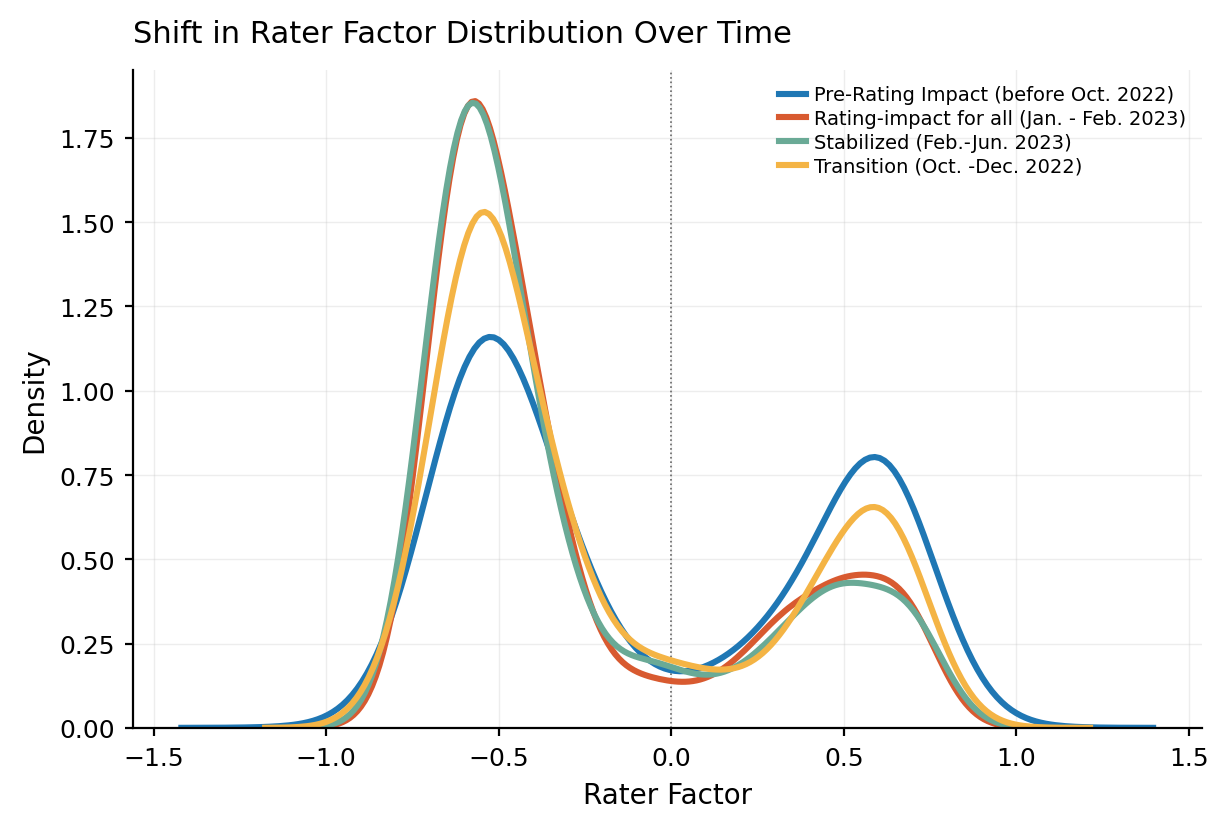

In [15]:
legacy_rater_df = rater_df[rater_df['raterParticipantId'].isin(legacy_users)]

# Prepare common dataframes
latest_rater_factors = legacy_rater_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
legacy_rater_df['month_str'] = legacy_rater_df['week_dt'].dt.strftime('%Y-%m')
legacy_rater_df['phase'] = legacy_rater_df['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(legacy_rater_df, 'raterFactor1', save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/rater_factor_distribution_shift_2022_legacy.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_1324750/965667393.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_1324750/965667393.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


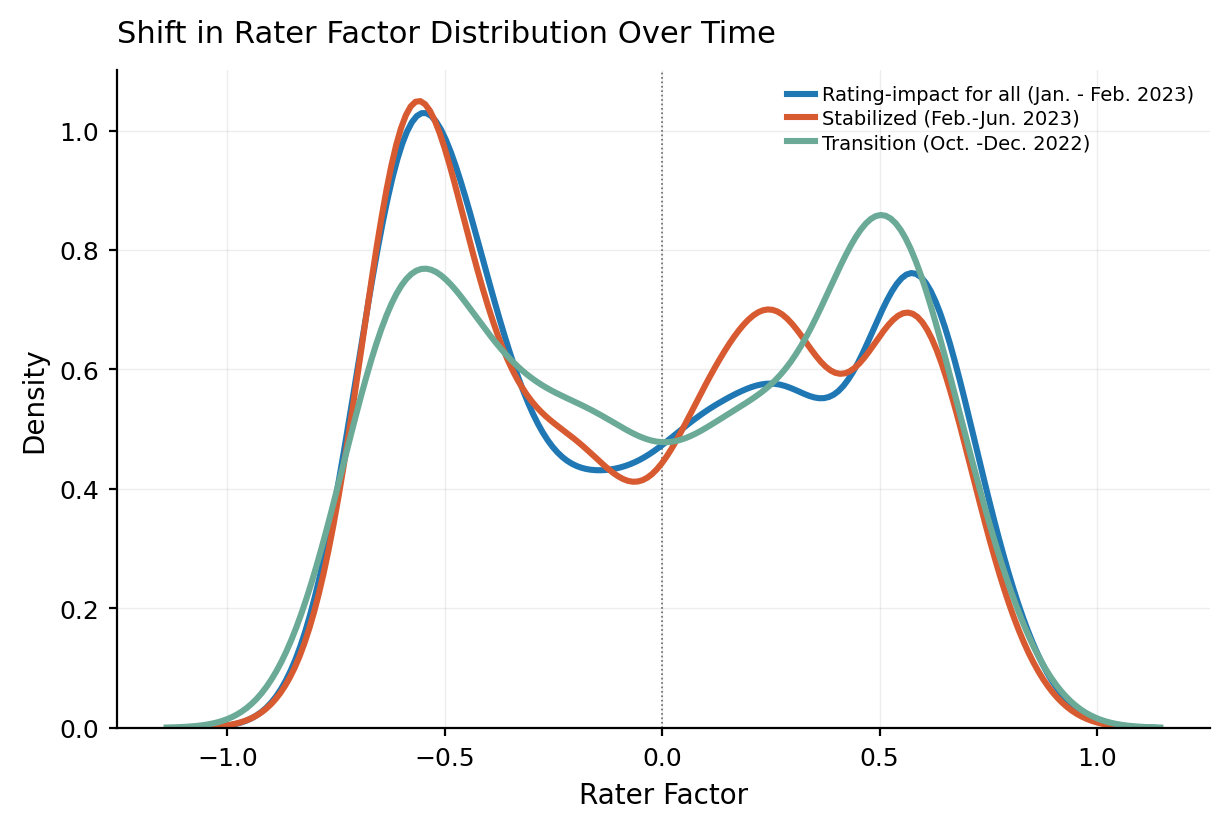

In [16]:
new_user_df = rater_df[rater_df['raterParticipantId'].isin(new_users)]

# Prepare common dataframes
latest_rater_factors = new_user_df.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
latest_note_factors = note_df_full.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
new_user_df['month_str'] = new_user_df['week_dt'].dt.strftime('%Y-%m')
new_user_df['phase'] = new_user_df['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(new_user_df, 'raterFactor1', save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/rater_factor_distribution_shift_2022_new.png')

# Appendix Figure 7


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_1324750/827806235.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_1324750/827806235.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


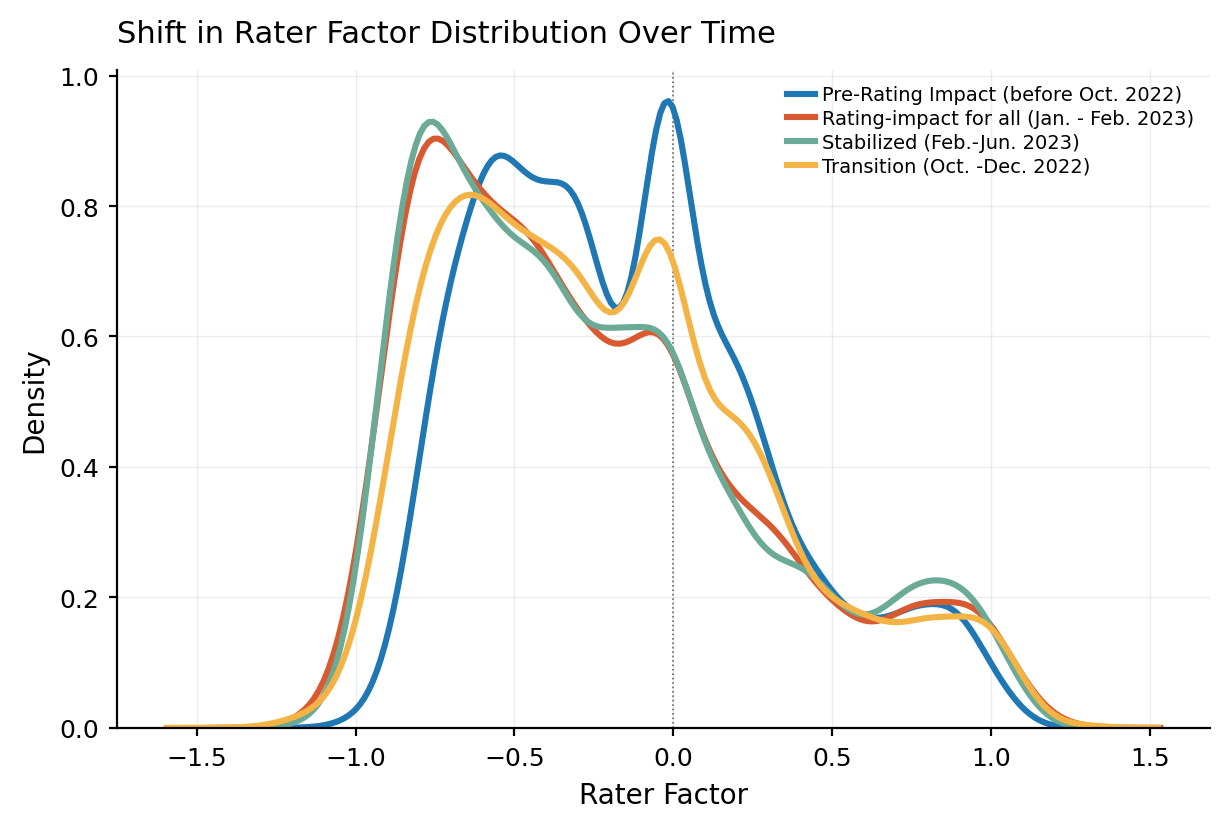

In [17]:
legacy_rater_df_2025 = rater_df_2025[rater_df_2025['raterParticipantId'].isin(legacy_users)]

# Prepare common dataframes
latest_rater_factors = legacy_rater_df_2025.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
# latest_note_factors = note_df_full_2025.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
legacy_rater_df_2025['month_str'] = legacy_rater_df_2025['week_dt'].dt.strftime('%Y-%m')
legacy_rater_df_2025['phase'] = legacy_rater_df_2025['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(legacy_rater_df_2025, 'raterFactor1', save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/rater_factor_distribution_shift_2025_legacy.png')


--- Slide 8 & 9: Factor Distribution Shifts ---


/tmp/ipykernel_1324750/2093857853.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_1324750/2093857853.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


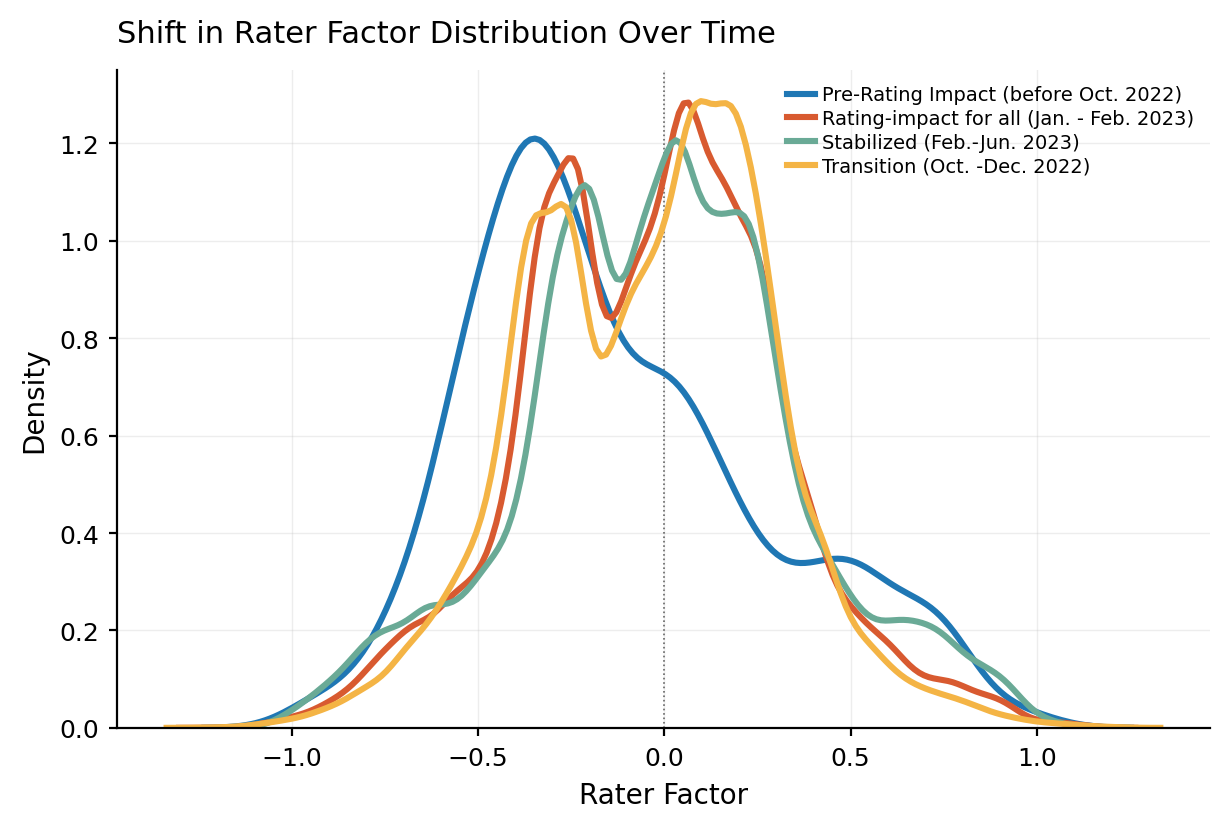

In [18]:
new_rater_df_2025 = rater_df_2025[rater_df_2025['raterParticipantId'].isin(new_users)]

# Prepare common dataframes
latest_rater_factors = new_rater_df_2025.sort_values('week_dt').drop_duplicates('raterParticipantId', keep='last')
# latest_note_factors = note_df_full_2025.sort_values('week_dt').drop_duplicates('noteId', keep='last')

# Slide 8 & 9: Factor Distribution Shifts
print("\n--- Slide 8 & 9: Factor Distribution Shifts ---")
new_rater_df_2025['month_str'] = new_rater_df_2025['week_dt'].dt.strftime('%Y-%m')
new_rater_df_2025['phase'] = new_rater_df_2025['month_str'].apply(assign_phase)
plot_factor_distribution_shifts(new_rater_df_2025, 'raterFactor1', save_path='/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/rater_factor_distribution_shift_2025_new.png')

# Appendix Figure 8

In [19]:
# measure the difference in factor shift for legacy vs. new users between oct. 1, 2022 to jan. 1, 2023
def compute_factor_shift(df, user_list, factor_col):
    df = df.copy()
    df['week_dt'] = pd.to_datetime(df['week_dt'])

    # First factor after Oct 1, 2022
    first_df = (
        df[
            (df['raterParticipantId'].isin(user_list)) &
            (df['week_dt'] > pd.Timestamp('2022-10-01'))
        ]
        .sort_values('week_dt')
        .groupby('raterParticipantId', as_index=False)
        .first()
        [['raterParticipantId', factor_col]]
        .rename(columns={factor_col: 'first_factor'})
    )

    # First factor after Jan 1, 2023
    last_df = (
        df[
            (df['raterParticipantId'].isin(user_list)) &
            (df['week_dt'] > pd.Timestamp('2023-01-01'))
        ]
        .sort_values('week_dt')
        .groupby('raterParticipantId', as_index=False)
        .first()
        [['raterParticipantId', factor_col]]
        .rename(columns={factor_col: 'last_factor'})
    )

    # Merge and compute shift
    out = first_df.merge(last_df, on='raterParticipantId', how='inner')
    out['factor_shift'] = out['last_factor'] - out['first_factor']

    return out


In [20]:
legacy_shift_2022 = compute_factor_shift(rater_df, legacy_users, 'raterFactor1')
new_shift_2022 = compute_factor_shift(rater_df, new_users, 'raterFactor1')

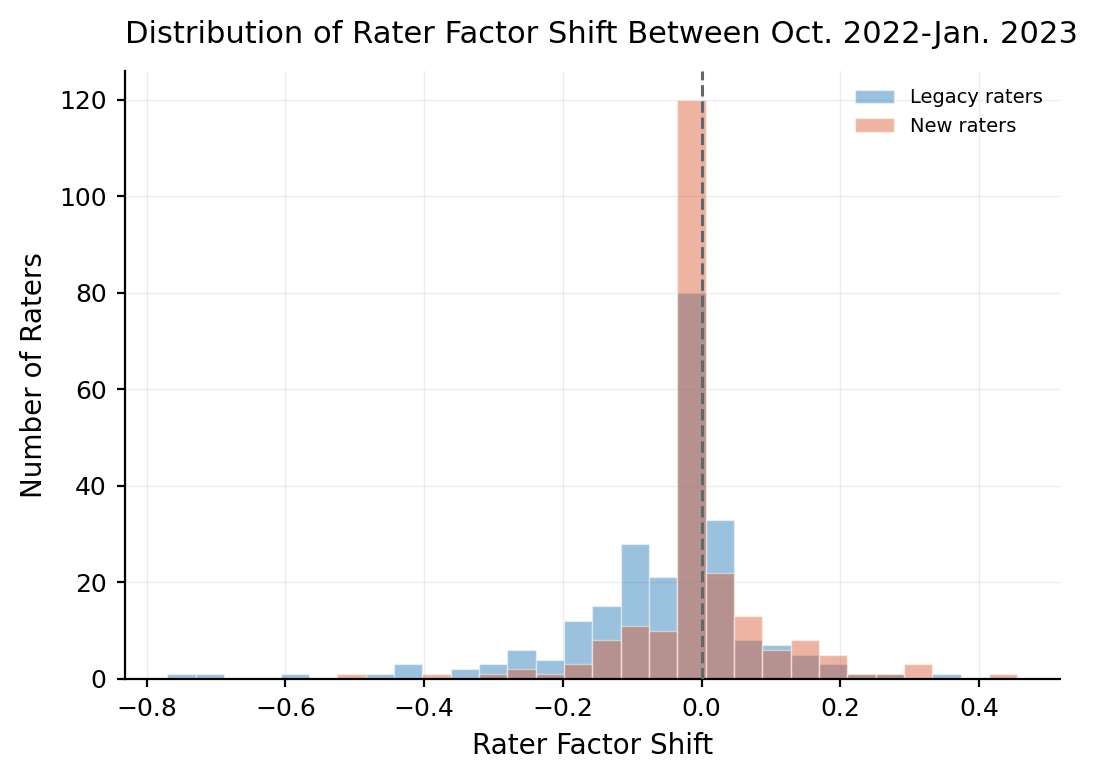

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 4))

bins = np.linspace(
    min(
        legacy_shift_2022["factor_shift"].dropna().min(),
        new_shift_2022["factor_shift"].dropna().min(),
    ),
    max(
        legacy_shift_2022["factor_shift"].dropna().max(),
        new_shift_2022["factor_shift"].dropna().max(),
    ),
    31,
)

ax.hist(
    legacy_shift_2022["factor_shift"].dropna(),
    bins=bins,
    alpha=0.45,
    label="Legacy raters",
    color=_C_BLUE,
    edgecolor="white",
    linewidth=0.5,
)

ax.hist(
    new_shift_2022["factor_shift"].dropna(),
    bins=bins,
    alpha=0.45,
    label="New raters",
    color=_C_ORANGE,
    edgecolor="white",
    linewidth=0.5,
)

ax.axvline(
    0,
    color=_C_ZERO,
    linewidth=1.1,
    linestyle="--",
    zorder=4,
)

ax.legend(
    frameon=False,
    fontsize=_FONT_LEGEND,
    loc="upper right",
)

_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Rater Factor Shift",
    ylabel="Number of Raters",
    title="Distribution of Rater Factor Shift Between Oct. 2022-Jan. 2023",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix",
)

In [22]:
legacy_mean = legacy_shift_2022["factor_shift"].mean()
new_mean    = new_shift_2022["factor_shift"].mean()
diff_means  = legacy_mean - new_mean

print(f"Legacy mean factor_shift: {legacy_mean:.6f}")
print(f"New mean factor_shift:    {new_mean:.6f}")
print(f"Difference (Legacy - New): {diff_means:.6f}")

Legacy mean factor_shift: -0.049158
New mean factor_shift:    0.003234
Difference (Legacy - New): -0.052392


In [23]:
rng = np.random.default_rng(0)
B = 10000  # bootstrap reps

x = legacy_shift_2022["factor_shift"].dropna().to_numpy()
y = new_shift_2022["factor_shift"].dropna().to_numpy()

# Bootstrap means for each group
x_boot_means = rng.choice(x, size=(B, x.size), replace=True).mean(axis=1)
y_boot_means = rng.choice(y, size=(B, y.size), replace=True).mean(axis=1)

x_mean = x.mean()
y_mean = y.mean()

x_ci_low, x_ci_high = np.percentile(x_boot_means, [2.5, 97.5])
y_ci_low, y_ci_high = np.percentile(y_boot_means, [2.5, 97.5])

print(f"Legacy mean factor_shift: {x_mean:.6f} (n={x.size})")
print(f"95% bootstrap CI:         [{x_ci_low:.6f}, {x_ci_high:.6f}]")
print()
print(f"New mean factor_shift:    {y_mean:.6f} (n={y.size})")
print(f"95% bootstrap CI:         [{y_ci_low:.6f}, {y_ci_high:.6f}]")


Legacy mean factor_shift: -0.049158 (n=237)
95% bootstrap CI:         [-0.066540, -0.032450]

New mean factor_shift:    0.003234 (n=218)
95% bootstrap CI:         [-0.010110, 0.016523]


# Appendix Figure 9

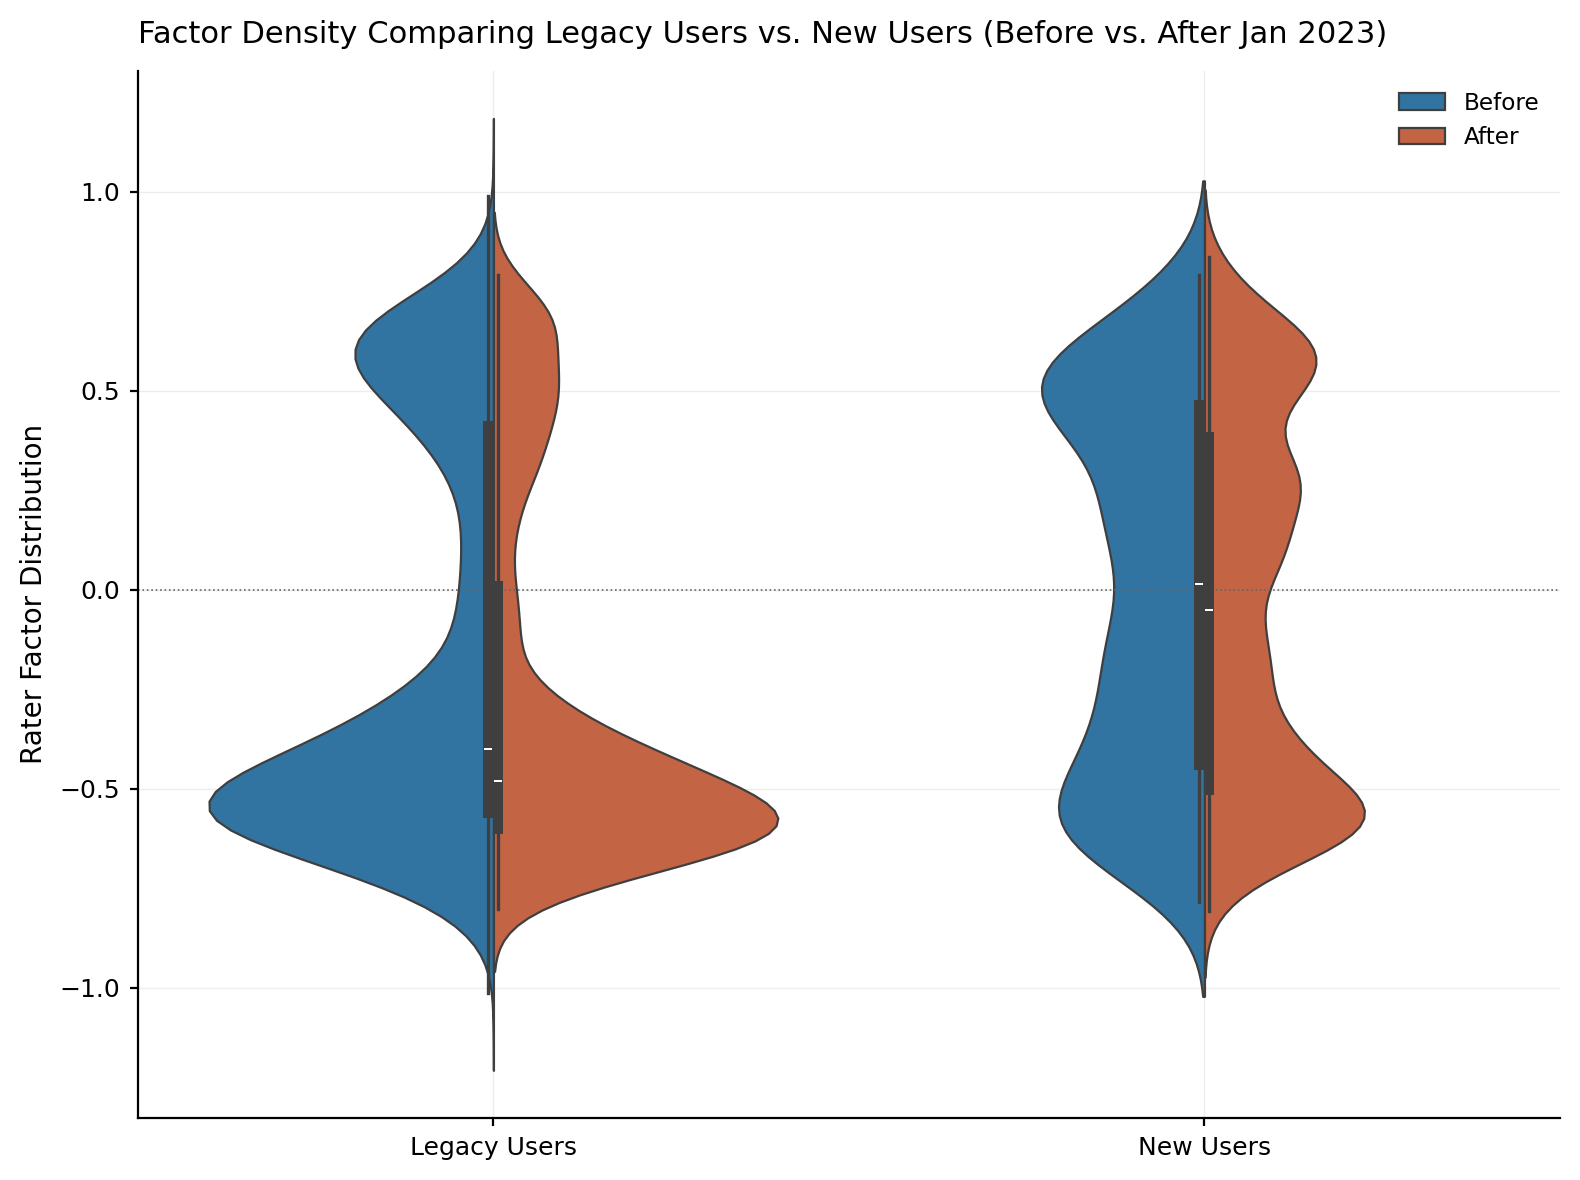

In [26]:
rater_df_legacy = rater_df[rater_df["raterParticipantId"].isin(legacy_users)].copy()
rater_df_new = rater_df[rater_df["raterParticipantId"].isin(new_users)].copy()

date_col = "week_dt"
cutoff = pd.Timestamp("2023-01-01")

# ensure datetime
rater_df_legacy[date_col] = pd.to_datetime(rater_df_legacy[date_col])
rater_df_new[date_col] = pd.to_datetime(rater_df_new[date_col])

# add labels
rater_df_legacy["Cohort"] = "Legacy Users"
rater_df_new["Cohort"] = "New Users"

rater_df_legacy["Period"] = pd.Series(pd.NA, index=rater_df_legacy.index)
rater_df_new["Period"] = pd.Series(pd.NA, index=rater_df_new.index)

rater_df_legacy["Period"] = (rater_df_legacy[date_col] < cutoff).map(
    {True: "Before", False: "After"}
)
rater_df_new["Period"] = (rater_df_new[date_col] < cutoff).map(
    {True: "Before", False: "After"}
)

rater_df_cohort = pd.concat(
    [
        rater_df_legacy[["Cohort", "Period", "raterFactor1"]],
        rater_df_new[["Cohort", "Period", "raterFactor1"]],
    ],
    ignore_index=True,
).dropna(subset=["raterFactor1", "Period"])

apply_publication_style()
fig, ax = plt.subplots(figsize=(8, 6))

sns.violinplot(
    data=rater_df_cohort,
    x="Cohort",
    y="raterFactor1",
    hue="Period",
    split=True,
    inner="box",
    palette=[_C_BLUE, _C_ORANGE],
    linewidth=0.8,
    ax=ax,
)

ax.axhline(0, color=_C_ZERO, linewidth=0.6, linestyle=":", zorder=1)
ax.legend(frameon=False, fontsize="small", loc="upper right", title=None)

_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="",
    ylabel="Rater Factor Distribution",
    title="Factor Density Comparing Legacy Users vs. New Users (Before vs. After Jan 2023)",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/rater_factor_violin_plot_2022.png",
)

# Appendix Figure 10

In [27]:
def bimodality_coefficient(data):
    g = skew(data)
    k = kurtosis(data, fisher=False)
    if k == 0:
        return np.nan
    return (g**2 + 1) / k

def compute_bc_over_time(df, factor_col, week_col='week_dt'):
    bc_over_time = []
    weeks = sorted(df[week_col].dropna().unique())[1:]  # skip first week if needed
    for week in weeks:
        data = df[df[week_col] == week][factor_col].dropna()
        if len(data) > 1:
            bc = bimodality_coefficient(data)
            bc_over_time.append({week_col: week, 'bimodality_coefficient': bc})
    return pd.DataFrame(bc_over_time)

In [28]:
bc_rater_df = compute_bc_over_time(rater_df_2025, 'raterFactor1')
bc_note_df  = compute_bc_over_time(note_df_full_2025, 'noteFactor1')

In [29]:
def run_rdd_on_bimodality(
    bc_df,
    label,
    cutoff_date="2022-10-01",
    title="RDD on bimodality coefficient",
    bandwidth_weeks=9,
):
    df = bc_df.copy()
    df['week_dt'] = pd.to_datetime(df['week_dt'])
    df = df.sort_values('week_dt')

    df['week_num'] = df['week_dt'].map(pd.Timestamp.toordinal)
    cutoff = pd.to_datetime(cutoff_date).toordinal()
    df['running'] = df['week_num'] - cutoff
    df['post'] = (df['running'] >= 0).astype(int)

    bw_days = bandwidth_weeks * 7
    df = df[df['running'].between(-bw_days, bw_days)].copy()

    model = smf.ols('bimodality_coefficient ~ running + post + running:post', data=df).fit(cov_type='HC3')
    df['fitted'] = model.fittedvalues

    apply_publication_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.0))
    ax.scatter(
        df['week_dt'],
        df['bimodality_coefficient'],
        label='Observed',
        color=_C_BLUE,
        alpha=0.55,
        s=22,
        linewidths=0,
        zorder=3,
    )
    ax.plot(df['week_dt'], df['fitted'], color=_C_ZERO, linewidth=2.0, label='RDD fit', zorder=4)
    ax.axvline(
        pd.to_datetime(cutoff_date),
        linestyle='--',
        color=_C_EVENT,
        linewidth=1.2,
        alpha=0.85,
        label='Rating Impact rollout',
        zorder=5,
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc='upper right')
    _setup_ax(ax)

    save_path = f"/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/rdd_bimodality_coefficient_{label}_{cutoff_date}.png"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    _finalize(
        fig,
        ax,
        xlabel='Week',
        ylabel='Bimodality Coefficient',
        title=f"{title}",
        save_path=save_path,
    )
    print(f"Figure saved to {save_path}")
    print(model.summary())
    return df, model

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1324750/4187158540.py:6: SyntaxWarning: invalid escape sequence '\p'


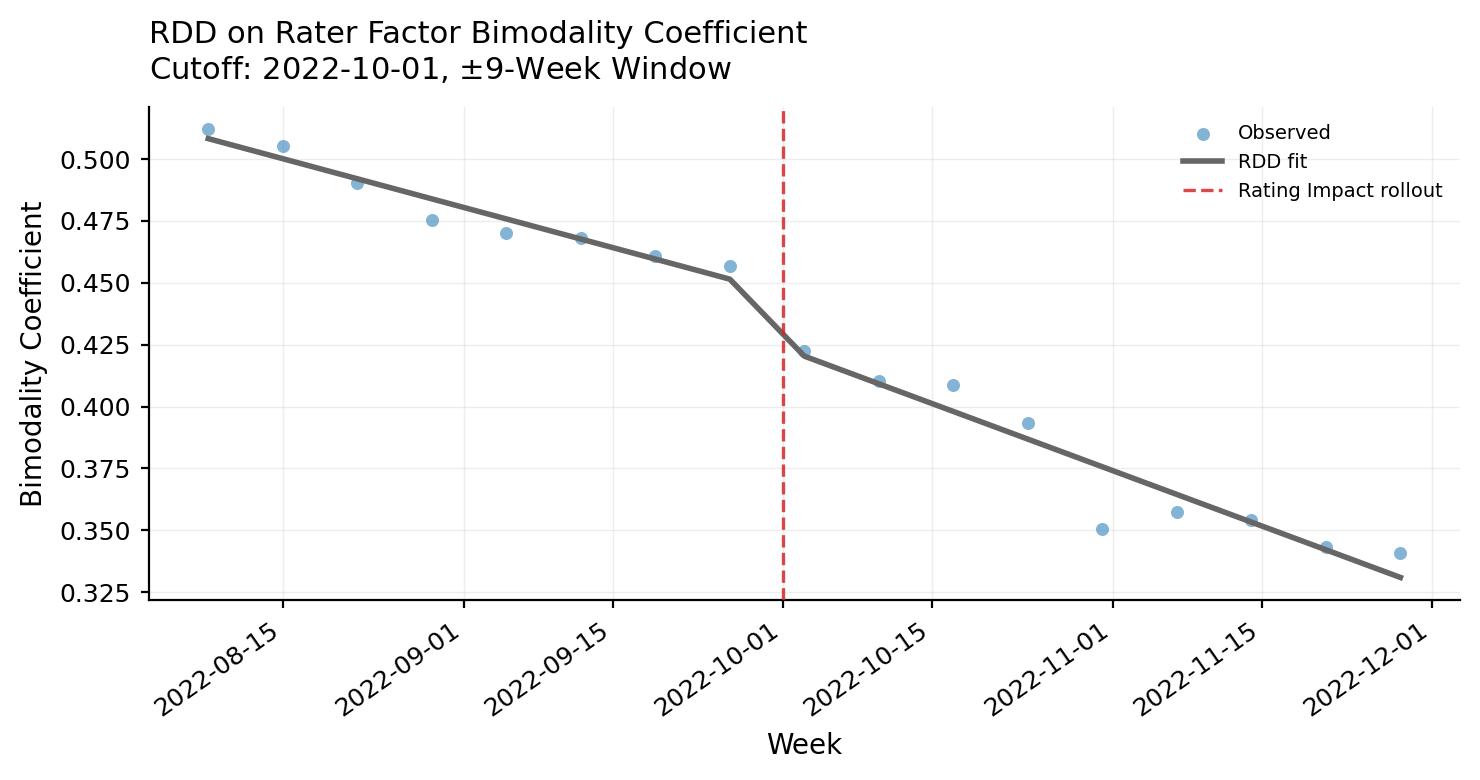

Figure saved to /accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/rdd_bimodality_coefficient_rater_2022-10-01.png
                              OLS Regression Results                              
Dep. Variable:     bimodality_coefficient   R-squared:                       0.981
Model:                                OLS   Adj. R-squared:                  0.976
Method:                     Least Squares   F-statistic:                     193.5
Date:                    Mon, 01 Jun 2026   Prob (F-statistic):           4.92e-11
Time:                            15:41:27   Log-Likelihood:                 57.786
No. Observations:                      17   AIC:                            -107.6
Df Residuals:                          13   BIC:                            -104.2
Df Model:                               3                                         
Covariance Type:                      HC3                                         
                   coef    std er

/usr/local/linux/miniforge-3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.


In [30]:
# Run on rater bimodality
df_rater_rdd, model_rater = run_rdd_on_bimodality(
    bc_rater_df,
    label="rater",
    cutoff_date="2022-10-01",
    title="RDD on Rater Factor Bimodality Coefficient \nCutoff: 2022-10-01, $\pm$9-Week Window"
)

# Appendix Figure 11

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1324750/460026352.py:6: SyntaxWarning: invalid escape sequence '\p'


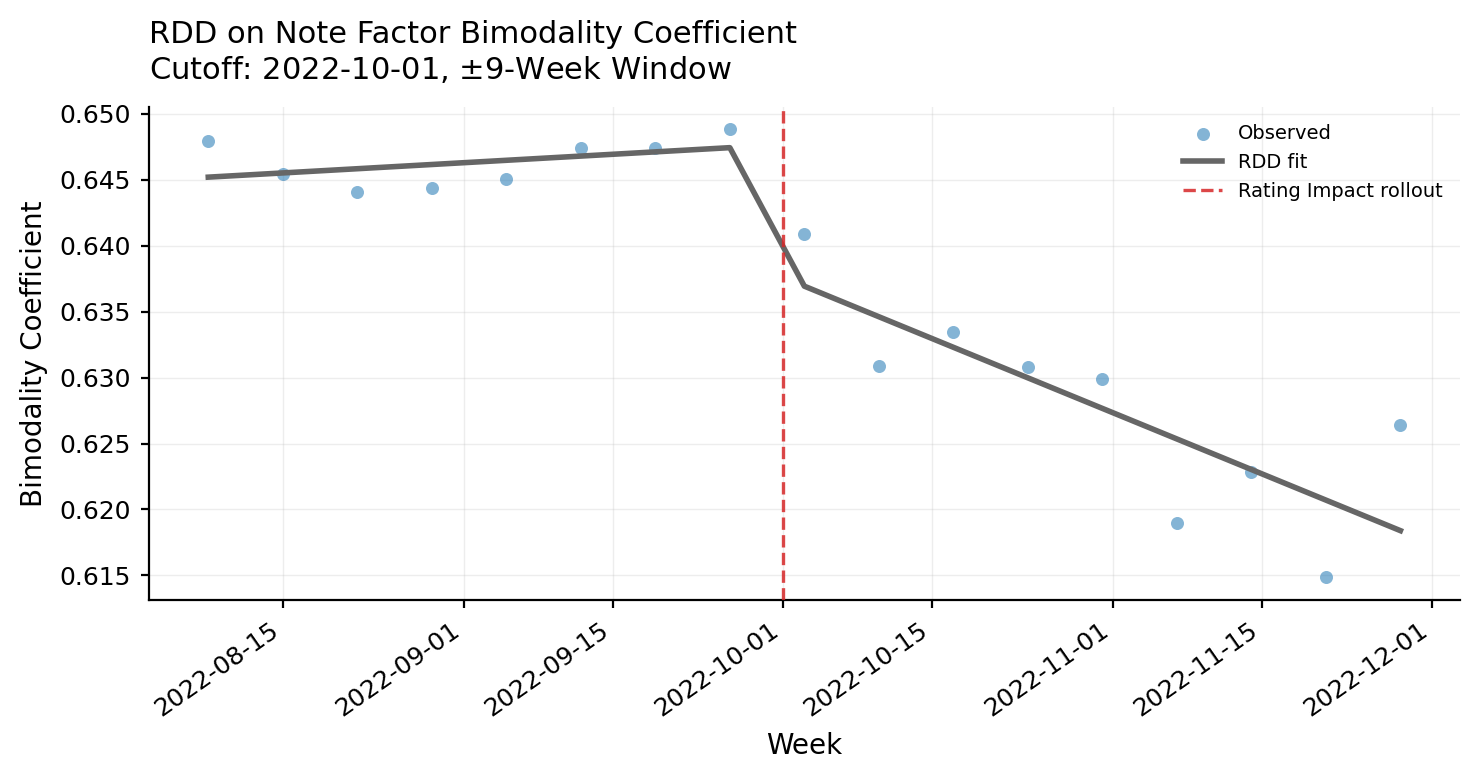

Figure saved to /accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/rdd_bimodality_coefficient_note_2022-10-01.png
                              OLS Regression Results                              
Dep. Variable:     bimodality_coefficient   R-squared:                       0.903
Model:                                OLS   Adj. R-squared:                  0.880
Method:                     Least Squares   F-statistic:                     27.16
Date:                    Mon, 01 Jun 2026   Prob (F-statistic):           7.18e-06
Time:                            15:41:54   Log-Likelihood:                 72.621
No. Observations:                      17   AIC:                            -137.2
Df Residuals:                          13   BIC:                            -133.9
Df Model:                               3                                         
Covariance Type:                      HC3                                         
                   coef    std err

/usr/local/linux/miniforge-3.13/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.


In [31]:
# Run on note bimodality
df_note_rdd, model_note = run_rdd_on_bimodality(
    bc_note_df,
    label="note",
    cutoff_date="2022-10-01",
    title="RDD on Note Factor Bimodality Coefficient\nCutoff: 2022-10-01, $\pm$9-Week Window"
)

# Appendix Figure 12

In [32]:
def prepare_rating_factors_over_time_weekly(ratings_df, note_df, rater_df):
    # Add week column to ratings
    rater_df['week_dt'] = pd.to_datetime(rater_df['week_dt']).dt.normalize()
    note_df['week_dt'] = pd.to_datetime(note_df['week_dt']).dt.normalize()
    ratings_df['week_dt'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms').dt.to_period('W').dt.start_time

    
    # Ensure note_df and rater_df also have 'week' column
    if 'week_dt' not in note_df.columns or 'week_dt' not in rater_df.columns:
        raise ValueError("note_df and rater_df must include a 'week' column for weekly merging.")
    
    ratings_df = ratings_df.sort_values(['week_dt'])
    note_df = note_df.sort_values([ 'week_dt'])
    rater_df = rater_df.sort_values(["week_dt"])

    # Merge_asof for note factors
    df = pd.merge_asof(
        ratings_df,
        note_df[['noteId', 'noteFactor1', 'noteIntercept', 'week_dt']],
        by='noteId',
        left_on='week_dt',
        right_on='week_dt',
        direction='backward',
        allow_exact_matches=False
    )

    # Ensure participant IDs are the same type (string is usually safest)
    rater_df["raterParticipantId"] = rater_df["raterParticipantId"].astype(str)
    df["raterParticipantId"] = df["raterParticipantId"].astype(str)
    
    # Merge with rater factors by raterParticipantId and week
    df = pd.merge_asof(
        left=df,
        right=rater_df[["raterParticipantId", "week_dt", "raterFactor1", 'raterIntercept']],
        by="raterParticipantId",
        left_on="week_dt",
        right_on="week_dt",
        direction="backward",
        allow_exact_matches=False
    )

    # Convert labels
    df['helpful_binary'] = np.where(
        df['helpfulnessLevel'] == 'HELPFUL', 1,
        np.where(df['helpfulnessLevel'] == 'NOT_HELPFUL', 0, np.nan)
    )

    # # Clean up
    df = df.dropna(subset=['noteFactor1', 'raterFactor1', 'helpful_binary'])

    # Label for coloring
    df['vote_label'] = df['helpful_binary'].map({1: 'Helpful', 0: 'Not Helpful'})

    return df


# Prepare data
df_plot = prepare_rating_factors_over_time_weekly(ratings_df, note_df_full_2025, rater_df_2025)

In [33]:
start = '2022-08-01'
end = '2023-01-01'

cutoff = '2022-10-01'

df_plot['week_dt'] = pd.to_datetime(df_plot['week_dt'])
df_plot = df_plot[(df_plot['week_dt'] >= start) & (df_plot['week_dt'] <= end)]
df_plot['dot_product'] = df_plot["noteFactor1"] * df_plot["raterFactor1"]
df_plot_legacy = df_plot[df_plot['raterParticipantId'].isin(legacy_users)]

df_plot_legacy.shape

(329, 13)

Corr before: 0.7921
Corr after: 0.5251
Observed diff: -0.2670
P-value: 0.0060


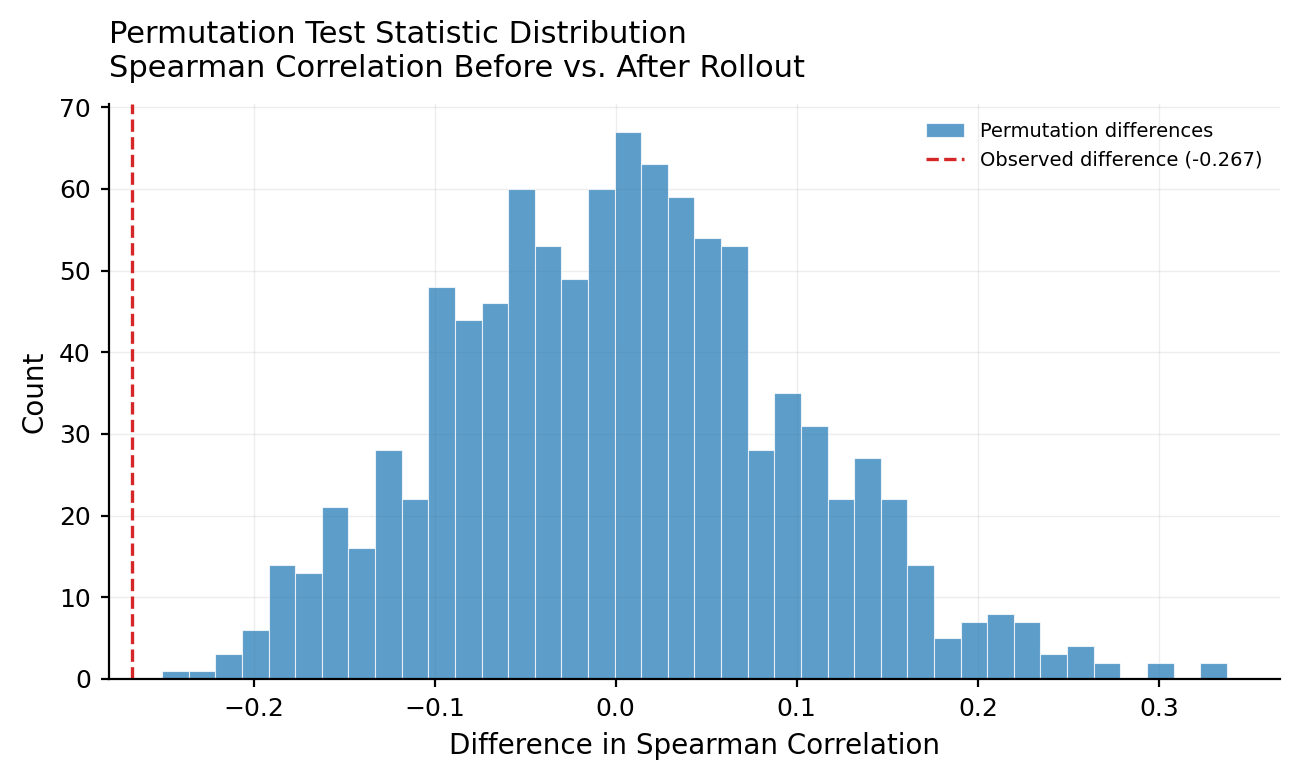

In [34]:
before = df_plot_legacy[df_plot_legacy['week_dt'] < cutoff]
after = df_plot_legacy[df_plot_legacy['week_dt'] > cutoff]

corr_before = spearmanr(before['dot_product'], before['helpful_binary']).correlation
corr_after = spearmanr(after['dot_product'], after['helpful_binary']).correlation
observed_diff = corr_after - corr_before
print(f'Corr before: {corr_before:.4f}')
print(f'Corr after: {corr_after:.4f}')
print(f'Observed diff: {observed_diff:.4f}')

all_data = pd.concat([before, after]).reset_index(drop=True)
n_before = len(before)
perm_diffs = []

for _ in range(1000):
    shuffled = all_data.sample(frac=1).reset_index(drop=True)
    perm_before = shuffled.iloc[:n_before]
    perm_after = shuffled.iloc[n_before:]

    c_before = spearmanr(perm_before['dot_product'], perm_before['helpful_binary']).correlation
    c_after = spearmanr(perm_after['dot_product'], perm_after['helpful_binary']).correlation
    perm_diffs.append(c_after - c_before)

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'P-value: {p_value:.4f}')

apply_publication_style()
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.hist(
    perm_diffs,
    bins=40,
    color=_C_BLUE,
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
    label="Permutation differences",
)
ax.axvline(
    observed_diff,
    color=_C_EVENT,
    linestyle="--",
    linewidth=1.2,
    label=f"Observed difference ({observed_diff:.3f})",
)
ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")
_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Difference in Spearman Correlation",
    ylabel="Count",
    title="Permutation Test Statistic Distribution \nSpearman Correlation Before vs. After Rollout",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/permutation_spearman.png",
)

# Appendix Figure 13

15.695666273372773
4.42689359385481
-11.268772679517962
Observed diff: -11.2688
P-value: 0.0010


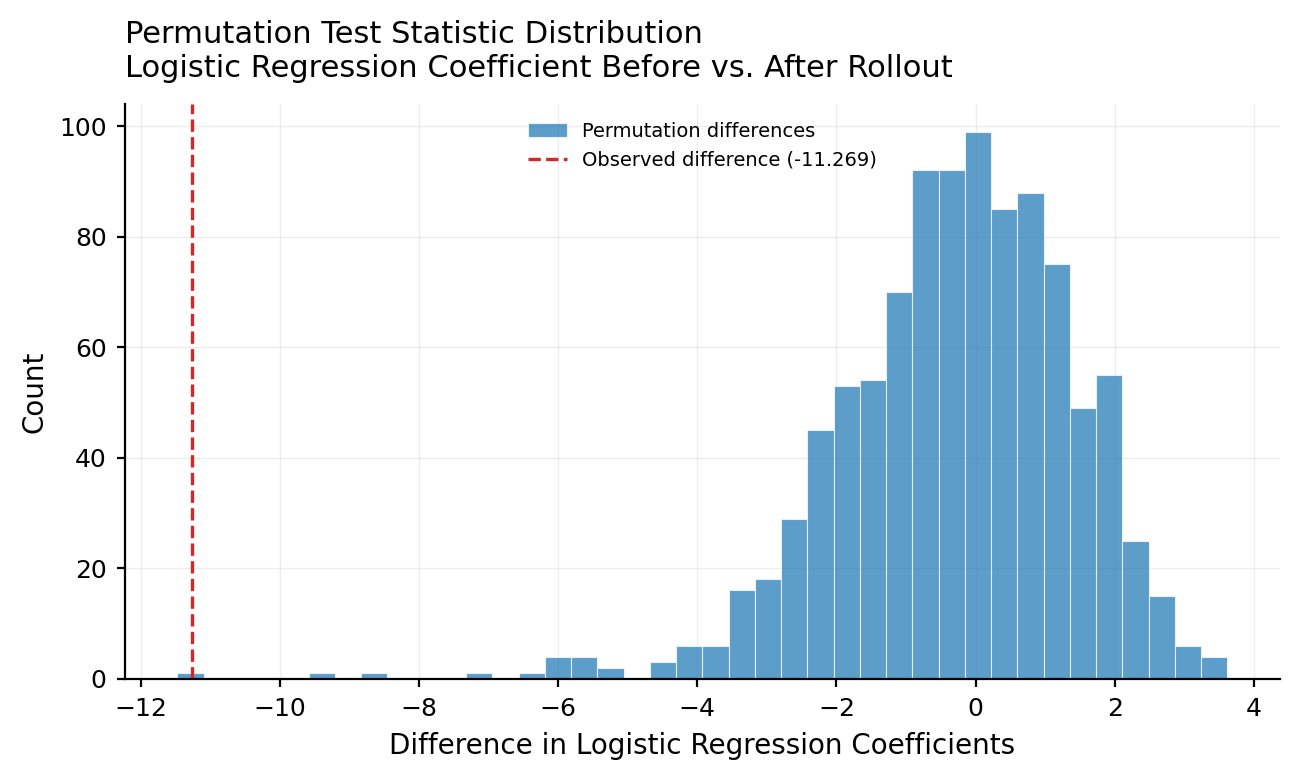

In [35]:
before = df_plot_legacy[df_plot_legacy['week_dt'] < cutoff]
after = df_plot_legacy[df_plot_legacy['week_dt'] > cutoff]

X_before = sm.add_constant(before['dot_product'])
y_before = before['helpful_binary']
model_before = sm.Logit(y_before, X_before).fit(disp=0)
coef_before = model_before.params['dot_product']

X_after = sm.add_constant(after['dot_product'])
y_after = after['helpful_binary']
model_after = sm.Logit(y_after, X_after).fit(disp=0)
coef_after = model_after.params['dot_product']
diff = coef_after - coef_before
print(coef_before)
print(coef_after)
print(diff)

all_data = df_plot_legacy
n_before = len(before)
observed_diff = coef_after - coef_before
perm_diffs = []

for _ in range(1000):
    shuffled = all_data.sample(frac=1).reset_index(drop=True)
    perm_before = shuffled.iloc[:n_before]
    perm_after = shuffled.iloc[n_before:]

    try:
        m_before = sm.Logit(
            perm_before['helpful_binary'],
            sm.add_constant(perm_before['dot_product']),
        ).fit(disp=0)
        m_after = sm.Logit(
            perm_after['helpful_binary'],
            sm.add_constant(perm_after['dot_product']),
        ).fit(disp=0)
        perm_diffs.append(m_after.params['dot_product'] - m_before.params['dot_product'])
    except Exception:
        continue

perm_diffs = np.array(perm_diffs)
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
print(f'Observed diff: {observed_diff:.4f}')
print(f'P-value: {p_value:.4f}')

apply_publication_style()
fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.hist(
    perm_diffs,
    bins=40,
    color=_C_BLUE,
    alpha=0.72,
    edgecolor="white",
    linewidth=0.4,
    label="Permutation differences",
)
ax.axvline(
    observed_diff,
    color=_C_EVENT,
    linestyle="--",
    linewidth=1.2,
    label=f"Observed difference ({observed_diff:.3f})",
)
ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper center")
_setup_ax(ax)
_finalize(
    fig,
    ax,
    xlabel="Difference in Logistic Regression Coefficients",
    ylabel="Count",
    title="Permutation Test Statistic Distribution \nLogistic Regression Coefficient Before vs. After Rollout",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/permutation_logistic.png",
)

# Appendix Table 5

In [36]:
BOW_TOPIC_PATH = "/accounts/projects/jchayes/commnotes/df_notes_with_topics.csv"
LLM_TOPIC_PATH = "/accounts/projects/jchayes/commnotes/notes_llm_topic.csv"

notes_bow_topic = pd.read_csv(BOW_TOPIC_PATH)
notes_llm_topic = pd.read_csv(LLM_TOPIC_PATH)

In [37]:
notes_df_bow = notes_df.merge(notes_bow_topic[['noteId', 'noteTopic']], how='left', on='noteId')
notes_df_llm = notes_df.merge(notes_llm_topic, how='left', left_on='noteId', right_on='NOTEID')

In [38]:
bow_missing = notes_df_bow["noteTopic"].isna().mean() * 100
print(f"X topic modeller, percentage of notes missing topic: {bow_missing:.2f}%")

llm_missing = notes_df_llm["TOPIC"].isna().mean() * 100
print(f"TOPIC modeller, percentage of notes missing topic: {llm_missing:.2f}%")

llama_missing = notes_df_llm["LLAMA4"].isna().mean() * 100
print(f"LLAMA4 modeller, percentage of notes missing topic: {llama_missing:.2f}%")

X topic modeller, percentage of notes missing topic: 64.22%
TOPIC modeller, percentage of notes missing topic: 28.79%
LLAMA4 modeller, percentage of notes missing topic: 31.11%


In [39]:
notes_df_topic_all = notes_df_bow.merge(notes_llm_topic, how='left', left_on='noteId', right_on='NOTEID')

In [40]:
df = notes_df_topic_all.copy()

a, b, c = "noteTopic", "TOPIC", "LLAMA4"

# optional: normalize whitespace / blanks to NA (keeps internal spaces unless you remove them elsewhere)
for col in [a, b, c]:
    df[col] = df[col].astype("string").str.strip().replace({"": pd.NA})

df["agree_all3"] = (df[[a, b, c]].notna().all(axis=1) & df[a].eq(df[b]) & df[a].eq(df[c])).astype("int8")
df["agree_ab"]   = (df[[a, b]].notna().all(axis=1) & df[a].eq(df[b])).astype("int8")
df["agree_ac"]   = (df[[a, c]].notna().all(axis=1) & df[a].eq(df[c])).astype("int8")
df["agree_bc"]   = (df[[b, c]].notna().all(axis=1) & df[b].eq(df[c])).astype("int8")

notes_with_topics_all = df

In [41]:
n_total = len(df)

# denominators: only notes where the compared models all have a (non-missing) topic
den_all3 = df[[a, b, c]].notna().all(axis=1).sum()
den_ab   = df[[a, b]].notna().all(axis=1).sum()
den_ac   = df[[a, c]].notna().all(axis=1).sum()
den_bc   = df[[b, c]].notna().all(axis=1).sum()

num_all3 = df["agree_all3"].sum()
num_ab   = df["agree_ab"].sum()
num_ac   = df["agree_ac"].sum()
num_bc   = df["agree_bc"].sum()

print(
    f"All 3 agree: {num_all3}/{n_total} ({(num_all3/n_total)*100:.2f}%) | "
    f"{num_all3}/{den_all3} among non-missing ({(num_all3/den_all3)*100:.2f}%)"
)
print(
    f"{a} & {b} agree: {num_ab}/{n_total} ({(num_ab/n_total)*100:.2f}%) | "
    f"{num_ab}/{den_ab} among non-missing ({(num_ab/den_ab)*100:.2f}%)"
)
print(
    f"{a} & {c} agree: {num_ac}/{n_total} ({(num_ac/n_total)*100:.2f}%) | "
    f"{num_ac}/{den_ac} among non-missing ({(num_ac/den_ac)*100:.2f}%)"
)
print(
    f"{b} & {c} agree: {num_bc}/{n_total} ({(num_bc/n_total)*100:.2f}%) | "
    f"{num_bc}/{den_bc} among non-missing ({(num_bc/den_bc)*100:.2f}%)"
)

All 3 agree: 4129/146401 (2.82%) | 4129/37916 among non-missing (10.89%)
noteTopic & TOPIC agree: 4334/146401 (2.96%) | 4334/38686 among non-missing (11.20%)
noteTopic & LLAMA4 agree: 4157/146401 (2.84%) | 4157/38056 among non-missing (10.92%)
TOPIC & LLAMA4 agree: 74495/146401 (50.88%) | 74495/99894 among non-missing (74.57%)


# Appendix Table 6

In [42]:
# Topic labels used for this DiD table.
notes_df_topic = notes_llm_topic.copy() if 'notes_llm_topic' in globals() else pd.read_csv('/accounts/projects/jchayes/commnotes/notes_llm_topic.csv')

In [43]:
# start_date = pd.to_datetime("2022-08-01")
partial_rollout_date = pd.to_datetime("2022-10-01")
full_rollout_date = pd.to_datetime("2023-01-01")

window = 12

In [44]:
ratings_df['createdAtDate'] = pd.to_datetime(ratings_df['createdAtMillis'], unit='ms')

# identify users who were present before initial rollout and who had a factor
old_user_ratings_df = ratings_df[ratings_df['createdAtDate'] < partial_rollout_date]
old_user_ids = old_user_ratings_df['raterParticipantId'].unique()

# get their factors before the partial rollout
old_user_rater_df_2025 = rater_df_2025[(rater_df_2025['week_dt'] < partial_rollout_date) & (rater_df_2025['raterParticipantId'].isin(old_user_ids))] 
old_user_rater_df_full_2025 = rater_df_2025[(rater_df_2025['raterParticipantId'].isin(old_user_ids))] 

In [45]:
# compute factors for old users before the full rollout_date
old_user_factors = pd.DataFrame(columns=[
    'raterParticipantId', 'firstFactor', 'firstFactorDate',
    'lastFactor', 'lastFactorDate', 'meanFactor'
])

old_user_factors = (
    old_user_rater_df_2025
    .sort_values(['raterParticipantId', 'week_dt'])
    .groupby('raterParticipantId')
    .agg(
        firstFactor=('raterFactor1', 'first'),
        firstFactorDate=('week_dt', 'first'),
        meanFactor=('raterFactor1', 'mean'),
        lastFactor=('raterFactor1', 'last'),
        lastFactorDate=('week_dt', 'last')
    )
    .reset_index()
)
old_user_factors['factorShift'] = old_user_factors['lastFactor'] - old_user_factors['firstFactor']

In [46]:
# process ratings data
ratings_df_with_topic = ratings_df.copy().merge(notes_df_topic, how='left', left_on='noteId', right_on='NOTEID')


# add controversy indicator
CONTROVERSIAL_TOPICS = [
    'USPolitics', 'UkraineConflict', 'GazaConflict',
    'CrimeLegal', 'HealthCovid', 'EconomyFinance','MessiRonaldo',  'politics', 'economy', 'health'
]

NON_CONTROVERSIAL_TOPICS = [
    'SpaceAstronomy', 'ClimateEnvironment', 'EntertainmentMoviesTV',
    'WeatherDisasters', 'TechCompanies', 'SportsNFL', 'SportsNBA',
    'FoodNutrition', 'Education', 'Scams',
    'ArtificialIntelligence', 'science', 'other'
]

ratings_df_with_topic['TOPIC'] = ratings_df_with_topic["TOPIC"].astype(str).str.strip().str.replace(r"\s+", "", regex=True)
ratings_df_with_topic['is_controversial'] = ratings_df_with_topic['TOPIC'].apply(
    lambda x: 1 if x in CONTROVERSIAL_TOPICS else (0 if x in NON_CONTROVERSIAL_TOPICS else np.nan)
)

ratings_df_with_topic.dropna(subset=['is_controversial'], inplace=True)
ratings_df_with_topic = ratings_df_with_topic.merge(old_user_factors, on='raterParticipantId', how='left')

# this is a dataframe with ratings only from users that were active before rating impact was initially rolled out
old_users = old_user_factors['raterParticipantId'].unique()
old_user_ratings_df = ratings_df_with_topic[ratings_df_with_topic['raterParticipantId'].isin(old_users)] 

old_user_ratings_df['week_dt'] = pd.to_datetime(old_user_ratings_df['createdAtDate']).dt.to_period('W').dt.start_time


/tmp/ipykernel_1324750/924506874.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [47]:
# out is a dataframe with columns: user, week_dt, n_ratings, n_controversial, raterFactor1, prop_controversial
out = (
    old_user_ratings_df
    .groupby(["raterParticipantId", "week_dt"], as_index=False)
    .agg(
        n_ratings=("noteId", "size"),
        n_controversial=("is_controversial", "sum"),  # bool/0-1
        raterFactor=("lastFactor", "first"),
    )
    .rename(columns={"raterParticipantId": "user"})
)
out = out[out['n_ratings'] >= 0]
out['prop_controversial'] = out['n_controversial'] / out['n_ratings']
out['log_n_ratings'] = np.log1p(out['n_ratings']+1)
out['log_n_controversial'] = np.log1p(out['n_controversial']+1)

In [48]:
out['minority'] = (out['raterFactor'] > 0.1).astype(int)

In [49]:
# function to run DiD
def run_did(df, outcome, minority_col, cutoff_date, window_weeks=12):
    d = df.copy()
    d["week_dt"] = pd.to_datetime(d["week_dt"])
    cutoff = pd.to_datetime(cutoff_date)

    # window
    lo = cutoff - pd.Timedelta(weeks=window_weeks)
    hi = cutoff + pd.Timedelta(weeks=window_weeks)
    d = d[(d["week_dt"] >= lo) & (d["week_dt"] < hi)].copy()

    # drop unknown treatment assignment
    d = d[d[minority_col].notna()].copy()

    # # Post + keep only users active both pre and post (within window)
    d["Post"] = (d["week_dt"] >= cutoff).astype(int)
    # pre_users  = set(d.loc[d["Post"] == 0, "user"])
    # post_users = set(d.loc[d["Post"] == 1, "user"])
    # keep_users = pre_users & post_users
    # d = d[d["user"].isin(keep_users)].copy()

    # interaction
    d["treat"] = d[minority_col] * d["Post"]

    panel = d.set_index(["user", "week_dt"]).sort_index()
    res = PanelOLS.from_formula(
        f"{outcome} ~ 1 + treat + EntityEffects + TimeEffects",
        data=panel,
        drop_absorbed=True
    ).fit(cov_type="clustered", cluster_entity=True)

    return res


In [50]:
# DiD prop, old users, initial rollout
res1 = run_did(out, outcome="prop_controversial", minority_col="minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     prop_controversial   R-squared:                        0.0017
Estimator:                   PanelOLS   R-squared (Between):             -0.0315
No. Observations:                4779   R-squared (Within):               0.0081
Date:                Mon, Jun 01 2026   R-squared (Overall):              0.0011
Time:                        15:44:10   Log-likelihood                   -1405.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.3811
Entities:                         955   P-value                           0.0116
Avg Obs:                       5.0042   Distribution:                  F(1,3800)
Min Obs:                       1.0000                                           
Max Obs:                       24.000   F-statistic (robust):             4.8077
                            

# Appendix Table 7

In [51]:
# DiD num, old users, initial rollout
res3 = run_did(out, outcome="log_n_ratings", minority_col="minority",
              cutoff_date=partial_rollout_date, window_weeks=12)
print(res3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:          log_n_ratings   R-squared:                        0.0034
Estimator:                   PanelOLS   R-squared (Between):             -0.2933
No. Observations:                4779   R-squared (Within):               0.0196
Date:                Mon, Jun 01 2026   R-squared (Overall):              0.0067
Time:                        15:44:11   Log-likelihood                   -2497.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      12.913
Entities:                         955   P-value                           0.0003
Avg Obs:                       5.0042   Distribution:                  F(1,3800)
Min Obs:                       1.0000                                           
Max Obs:                       24.000   F-statistic (robust):             3.6925
                            

# Appendix Table 8

In [52]:
# Compute factor scores using only pre-intervention data
pre_notes = note_df_full[note_df_full['week_dt'] < pd.to_datetime("2022-10-01")]
note_distribution_df = pre_notes.groupby('noteId')['noteFactor1'].mean().reset_index()

# Fit quantile cutoffs on pre-period only, then apply to all notes
pre_low  = note_distribution_df['noteFactor1'].quantile(0.10)
pre_high = note_distribution_df['noteFactor1'].quantile(0.90)

all_notes = note_df_full.groupby('noteId')['noteFactor1'].mean().reset_index()
all_notes['controversial'] = (
    (all_notes['noteFactor1'] <= pre_low) | (all_notes['noteFactor1'] >= pre_high)
).astype(int)
factor_q_df = all_notes
factor_q_df = factor_q_df.merge(notes_df[['noteId', 'tweetId']], on='noteId', how='left')

In [53]:
# --- helpers ---------------------------------------------------------------
def _wilson_ci(k, n, z=1.96):
    """Wilson score interval for a binomial proportion."""
    k = np.asarray(k, dtype=float)
    n = np.asarray(n, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        phat = np.where(n > 0, k / n, np.nan)
        denom = 1 + z**2 / n
        center = (phat + (z**2) / (2*n)) / denom
        margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
        lo = center - margin
        hi = center + margin
    return lo, hi

def _weighted_centered_rolling(values, weights, window):
    """Centered, weight-aware rolling mean (nan-safe)."""
    s = pd.Series(values, dtype=float)
    w = pd.Series(weights, dtype=float)
    def _avg(x):
        v = x.values
        ww = w.iloc[x.index].values
        mask = ~np.isnan(v) & ~np.isnan(ww) & (ww > 0)
        return np.average(v[mask], weights=ww[mask]) if mask.any() else np.nan
    return s.rolling(window=window, center=True, min_periods=1).apply(_avg, raw=False)

In [54]:
# --- main calc -------------------------------------------------------------

def calculate_controversy_proportions_principled(
    status_history_df: pd.DataFrame,
    notes_df: pd.DataFrame,
    time: str = "W",
    min_n: int = 30,               # hide points with fewer than min_n denominators
    smooth_window: int = 7,        # centered window length for smoothing
    jeffreys_alpha: float = 0.5,   # Jeffreys prior for shrinkage
    jeffreys_beta: float = 0.5
) -> pd.DataFrame:
    """
    Weekly proportions by topic category with:
      - category-specific denominators (unique tweets seeing their first note in that category)
      - Jeffreys-shrunk proportions to stabilize small n
      - Wilson 95% CIs
      - weighted, centered rolling smoothing (by denominator)
      - NaN where denominator < min_n (kept for plotting masks)
    """
    # make sure both keys are the same dtype
    status_history_df = status_history_df.copy()
    notes_df = notes_df.copy()
    
    status_history_df["noteId"] = status_history_df["noteId"].astype("string")
    notes_df["noteId"] = notes_df["noteId"].astype("string")
    
    # Merge & prepare
    df = pd.merge(status_history_df, notes_df, on='noteId', how='right',
                  suffixes=('_status', '_note'))
    
    print(df.columns)
    df['note_creation_dt'] = pd.to_datetime(df['createdAtMillis'], unit='ms')
    
    # --- ensure controversy flag and category labels ---
    df['controversial'] = pd.to_numeric(df['controversial'], errors='coerce').astype('Int64')
    
    df['topic_category'] = df['controversial'].map({
        1: 'Controversial',
        0: 'Non-Controversial'
    }).astype('string')

    out = []

    for category in df['topic_category'].dropna().unique():
        cdf = df[df['topic_category'] == category]

        # denominator: first time each tweet gets ANY note in this category
        denom_idx = cdf.groupby('tweetId')['note_creation_dt'].min()
        denom = denom_idx.value_counts().resample(time).sum().fillna(0).rename('denominator_tweets')

        # helpful / unhelpful: first time each tweet gets a note with that final status in this category
        helpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()
        unhelpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_NOT_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()

        helpful = helpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'helpful_{category}')
        unhelpful = unhelpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'unhelpful_{category}')

        # raw proportions (nan where n=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            p_help = np.where(denom.values > 0, helpful.values / denom.values, np.nan)
            p_unhl = np.where(denom.values > 0, unhelpful.values / denom.values, np.nan)

        # Jeffreys-shrunk estimates
        ph_shrunk = (helpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        pu_shrunk = (unhelpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        ph_shrunk = np.where(denom.values > 0, ph_shrunk, np.nan)
        pu_shrunk = np.where(denom.values > 0, pu_shrunk, np.nan)

        # Wilson CIs (on raw proportions)
        ph_lo, ph_hi = _wilson_ci(helpful.values, denom.values)
        pu_lo, pu_hi = _wilson_ci(unhelpful.values, denom.values)

        # mask tiny denominators
        mask = denom.values >= min_n
        def _mask(arr):
            arr = np.asarray(arr, dtype=float)
            arr[~mask] = np.nan
            return arr

        # smooth (weighted by denominators)
        ph_smooth = _weighted_centered_rolling(_mask(ph_shrunk), denom.values, smooth_window)
        pu_smooth = _weighted_centered_rolling(_mask(pu_shrunk), denom.values, smooth_window)

        cat_df = pd.DataFrame({
            'week_dt': denom.index,
            'denominator_tweets_' + category: denom.values,
            f'helpful_{category}': helpful.values,
            f'unhelpful_{category}': unhelpful.values,
            f'prop_helpful_raw_{category}': _mask(p_help),
            f'prop_unhelpful_raw_{category}': _mask(p_unhl),
            f'prop_helpful_shrunk_{category}': _mask(ph_shrunk),
            f'prop_unhelpful_shrunk_{category}': _mask(pu_shrunk),
            f'prop_helpful_lo_{category}': _mask(ph_lo),
            f'prop_helpful_hi_{category}': _mask(ph_hi),
            f'prop_unhelpful_lo_{category}': _mask(pu_lo),
            f'prop_unhelpful_hi_{category}': _mask(pu_hi),
            f'prop_helpful_smooth_{category}': ph_smooth.values,
            f'prop_unhelpful_smooth_{category}': pu_smooth.values,
        })
        out.append(cat_df)

    # outer-merge all categories on week_dt
    result = out[0]
    for k in out[1:]:
        result = pd.merge(result, k, on='week_dt', how='outer')

    result = result.sort_values('week_dt').reset_index(drop=True)
    return df, result

# --- plotting --------------------------------------------------------------

def plot_controversy_trends_principled(df: pd.DataFrame, save_path=None):
    """
    Plot smoothed, shrunken proportions with faint raw points and Wilson CIs.
    Points with denominator < min_n are hidden (NaN).
    """
    cats = sorted({c.split('_')[-1] for c in df.columns if c.startswith('prop_helpful_smooth_')})
    colors = [_C_ORANGE, _C_BLUE] + _MUTED_PALETTE[2:]

    apply_publication_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    x = pd.to_datetime(df['week_dt'])

    for cat, color in zip(cats, colors):
        helpful = df[f'prop_helpful_smooth_{cat}']
        unhelpful = df[f'prop_unhelpful_smooth_{cat}']

        ax.plot(x, helpful, color=color, linewidth=2.2, label=f'Helpful: {cat}', zorder=4)
        ax.plot(x, unhelpful, color=color, linewidth=1.8, linestyle='--', alpha=0.85, label=f'Not helpful: {cat}', zorder=4)
        ax.scatter(x, df[f'prop_helpful_shrunk_{cat}'], s=10, color=color, alpha=0.22, linewidths=0, zorder=2)
        ax.scatter(x, df[f'prop_unhelpful_shrunk_{cat}'], s=10, color=color, alpha=0.18, marker='x', zorder=2)

        ax.fill_between(
            x,
            df[f'prop_helpful_lo_{cat}'].astype(float),
            df[f'prop_helpful_hi_{cat}'].astype(float),
            color=color,
            alpha=0.10,
            linewidth=0,
            zorder=1,
        )

    ax.set_ylim(-0.01, 0.45)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc='upper right', ncol=2)
    _setup_ax(ax)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
    _finalize(
        fig,
        ax,
        xlabel='Date',
        ylabel='Proportion',
        title='Smoothed final-status proportions by topic category',
        save_path=save_path,
    )

In [55]:
# --- usage -----------------------------------------------------------------
l_df, p_df = calculate_controversy_proportions_principled(history_df,
                                                    factor_q_df, 
                                                          time="W",
                                                    min_n=6, smooth_window=9)
# plot_controversy_trends_principled(p_df[p_df["week_dt"]<"2024-12"])

Index(['noteId', 'noteAuthorParticipantId', 'createdAtMillis',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime', 'noteFactor1',
       'controversial', 'tweetId'],
      dtype='object')


In [56]:
def _prepare_long_from_panel(panel_df, treated="Non-Controversial", control="Controversial",
                             min_n=30, use_jeffreys=True):
    """
    Returns long df with one row per (week, topic): week_dt, topic_type, prop, n_raw.
    prop uses Jeffreys smoothing for stability; n_raw is the raw denominator for weights.
    """
    df = panel_df.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])

    out = []
    for topic in (treated, control):
        k_raw = df[f"helpful_{topic}"].astype(float)
        n_raw = df[f"denominator_tweets_{topic}"].astype(float)

        # Smoothed proportion for stability, but keep RAW n for weights
        if use_jeffreys:
            k = k_raw + 0.5
            n = n_raw + 1.0
        else:
            k, n = k_raw, n_raw

        prop = np.where(n_raw > 0, k / n, np.nan)
        keep = (n_raw >= min_n) & np.isfinite(prop)

        out.append(pd.DataFrame({
            "week_dt": df["week_dt"],
            "topic_type": topic,
            "prop": pd.Series(prop).where(keep),
            "n_raw": n_raw.where(keep)
        }))

    long_df = pd.concat(out, ignore_index=True).dropna(subset=["prop", "n_raw"])
    return long_df


def _weekly_diff_series(long_df, treated, control, weight_mode="min"):
    """
    Balanced weekly difference series:
      diff_t = prop_treated_t - prop_control_t
      w_t    = min(n_treated_t, n_control_t) or sum(...), per weight_mode.
    """
    wide = long_df.pivot(index="week_dt", columns="topic_type", values=["prop", "n_raw"])
    props = wide["prop"]
    ns = wide["n_raw"]

    if treated not in props or control not in props:
        raise ValueError("After filtering, one of the topics is missing. Check names and min_n.")

    # Keep only weeks where both are observed
    diff = (props[treated] - props[control]).dropna()
    n_t = ns[treated].reindex(diff.index)
    n_c = ns[control].reindex(diff.index)

    if weight_mode == "sum":
        w = (n_t + n_c).astype(float)
    else:  # default "min"
        w = np.minimum(n_t, n_c).astype(float)

    w = w.clip(lower=1.0)

    series = pd.DataFrame({"diff": diff.astype(float), "w": w.astype(float)})
    series.index.name = "week_dt"
    return series


def _fit_window(y, w, is_post, hac_maxlags=4):
    """
    WLS diff-in-means (pre vs post) with HAC standard errors.
    y, w, is_post can be numpy arrays or pandas Series.
    """
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)
    is_post = np.asarray(is_post, dtype=float)

    X = sm.add_constant(is_post)
    fit = sm.WLS(y, X, weights=w).fit(cov_type="HAC", cov_kwds={"maxlags": hac_maxlags})

    est = float(fit.params[1])
    se = float(fit.bse[1])
    p = float(fit.pvalues[1])
    z = 1.96
    ci = (est - z * se, est + z * se)
    return {"est": est, "se": se, "ci": ci, "p": p}


def did_windows_v2(panel_df,
                   change_date="2022-12-15",
                   treated="Non-Controversial",
                   control="Controversial",
                   pre_weeks=8,
                   short_post_weeks=8,
                   medium_post_weeks=(9, 26),
                   min_n=30,
                   use_jeffreys=True,
                   weight_mode="min",
                   hac_maxlags=4):
    """
    Short- and medium-run DiD on weekly helpfulness differences.
    Returns dict with 'short', 'medium', 'series', and 'meta'.
    """
    # Build balanced weekly diff series
    long_df = _prepare_long_from_panel(panel_df, treated, control, min_n, use_jeffreys)
    series = _weekly_diff_series(long_df, treated, control, weight_mode)
    series = series.sort_index()
    change_dt = pd.to_datetime(change_date)

    weeks = series.index

    # Pre window: last `pre_weeks` weeks strictly before the change
    pre_weeks_idx = weeks[weeks < change_dt]
    pre_weeks_idx = pre_weeks_idx[-pre_weeks:]  # if fewer exist, we take all available

    # Short post: from change_dt inclusive, take the next `short_post_weeks` observed weeks
    short_post_all = weeks[weeks >= change_dt]
    short_idx = short_post_all[:short_post_weeks]

    # Medium post: (lo, hi) weeks after change (inclusive)
    m_lo, m_hi = medium_post_weeks
    med_start = change_dt + pd.Timedelta(weeks=m_lo)
    med_end = change_dt + pd.Timedelta(weeks=m_hi)
    med_idx = weeks[(weeks >= med_start) & (weeks <= med_end)]

    def _run_window(idx_post):
        # aligned boolean masks (as Series) to avoid reindex warnings
        pre_mask = pd.Series(series.index.isin(pre_weeks_idx), index=series.index)
        post_mask = pd.Series(series.index.isin(idx_post), index=series.index)
        keep = pre_mask | post_mask

        y = series.loc[keep, "diff"]
        w = series.loc[keep, "w"]
        is_post = post_mask.loc[keep]

        # guard rails
        if y.size < 4 or is_post.sum() == 0 or (~is_post).sum() == 0:
            return {
                "est": np.nan, "se": np.nan, "ci": (np.nan, np.nan), "p": np.nan,
                "n_pre": int((~is_post).sum()), "n_post": int(is_post.sum()),
                "weeks_pre": list(pre_weeks_idx.astype(str)),
                "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
            }

        out = _fit_window(y.to_numpy(), w.to_numpy(), is_post.to_numpy(), hac_maxlags=hac_maxlags)
        out.update({
            "n_pre": int((~is_post).sum()),
            "n_post": int(is_post.sum()),
            "weeks_pre": list(pre_weeks_idx.astype(str)),
            "weeks_post": list(pd.DatetimeIndex(idx_post).astype(str)),
        })
        return out

    short_res = _run_window(short_idx)
    medium_res = _run_window(med_idx)

    return {
        "short": short_res,
        "medium": medium_res,
        "series": series.reset_index(),  # columns: week_dt, diff, w
        "meta": {
            "change_date": str(pd.to_datetime(change_date).date()),
            "pre_weeks": pre_weeks,
            "short_post_weeks": short_post_weeks,
            "medium_post_weeks": medium_post_weeks,
            "min_n": min_n,
            "weight_mode": weight_mode,
            "use_jeffreys": use_jeffreys,
            "hac_maxlags": hac_maxlags,
            "treated": treated,
            "control": control,
        },
    }


In [57]:
res = did_windows_v2(
    p_df,
    change_date="2022-10-01",
    treated="Non-Controversial",
    control="Controversial",
    pre_weeks=14,                # short-run baseline window
    short_post_weeks=14,          # short-run post
    medium_post_weeks=(14, 28),   # medium-run post
    min_n=1,                    # require both groups to have ≥1 tweets that week
    use_jeffreys=True,
    weight_mode="min",           # or "sum"
    hac_maxlags=4
)

print(res["short"])    # dict: est, se, ci, p, n_pre, n_post, weeks_pre, weeks_post
print(res["medium"])   # same for the medium window
res["series"].head() 

{'est': 0.13818552646693455, 'se': 0.06390493323979105, 'ci': (0.012931857316944101, 0.26343919561692497), 'p': 0.030590371922680507, 'n_pre': 14, 'n_post': 14, 'weeks_pre': ['2022-06-19', '2022-06-26', '2022-07-03', '2022-07-10', '2022-07-24', '2022-07-31', '2022-08-07', '2022-08-14', '2022-08-21', '2022-08-28', '2022-09-04', '2022-09-11', '2022-09-18', '2022-09-25'], 'weeks_post': ['2022-10-02', '2022-10-09', '2022-10-16', '2022-10-23', '2022-10-30', '2022-11-06', '2022-11-13', '2022-11-20', '2022-11-27', '2022-12-04', '2022-12-11', '2022-12-18', '2022-12-25', '2023-01-01']}
{'est': 0.2389075740390632, 'se': 0.04365744880301877, 'ci': (0.15333897438514643, 0.32447617369298), 'p': 4.4417931552647946e-08, 'n_pre': 14, 'n_post': 9, 'weeks_pre': ['2022-06-19', '2022-06-26', '2022-07-03', '2022-07-10', '2022-07-24', '2022-07-31', '2022-08-07', '2022-08-14', '2022-08-21', '2022-08-28', '2022-09-04', '2022-09-11', '2022-09-18', '2022-09-25'], 'weeks_post': ['2023-01-08', '2023-01-15', '2023

,week_dt,diff,w
0,2021-08-29,0.291667,3.0
1,2021-09-05,-0.202381,5.0
2,2021-09-12,0.250000,2.0
3,2021-09-19,-0.083333,1.0
4,2021-09-26,0.000000,1.0


# Appendix Table 9

In [58]:
# notes_df.head()

notes_llm_topic['TOPIC'] = notes_llm_topic['TOPIC'].str.replace(' ', '', regex=False)
notes_llm_topic['LLAMA4'] = notes_llm_topic['LLAMA4'].str.replace(' ', '', regex=False)


notes_with_topic_all = notes_df.merge(notes_bow_topic[['noteId', 'noteTopic']], on='noteId', how='left')
notes_with_topic_all = notes_with_topic_all.merge(notes_llm_topic[['NOTEID', 'TOPIC', 'LLAMA4']], left_on='noteId', right_on='NOTEID', how='left')

In [59]:
cutoff_date = '2022-10-01'
end_date = pd.Timestamp(cutoff_date) + pd.Timedelta(weeks=12)

In [60]:
for topic_col in ['noteTopic', 'TOPIC', 'LLAMA4']:
    notes_with_topic_all["controversial"] = np.select(
        [
            notes_with_topic_all[topic_col].isin(CONTROVERSIAL_TOPICS),
            notes_with_topic_all[topic_col].isin(NON_CONTROVERSIAL_TOPICS),
        ],
        [1, 0],
        default=pd.NA,
    )
    ratings_with_topic = ratings_df.merge(
        notes_with_topic_all[['noteId', topic_col, 'controversial']],
        on='noteId', how='left'
    )

    ratings_with_topic_clean = ratings_with_topic.dropna(subset=['controversial'])
    ratings_with_topic_clean['controversial'] = pd.to_numeric(ratings_with_topic_clean['controversial'], errors='coerce')

    pre_ratings  = ratings_with_topic_clean[ratings_with_topic_clean['createdAtDate'] < cutoff_date]
    post_ratings = ratings_with_topic_clean[(ratings_with_topic_clean['createdAtDate'] > cutoff_date) & (ratings_with_topic_clean['createdAtDate'] < end_date)]

    pre_con  = int(pre_ratings['controversial'].sum())
    pre_non  = int((pre_ratings['controversial'] == 0).sum())
    post_con = int(post_ratings['controversial'].sum())
    post_non = int((post_ratings['controversial'] == 0).sum())

    odds_ratio, p_fisher = fisher_exact(np.array([[pre_con, pre_non], [post_con, post_non]]))

    print(f"\n--- {topic_col} ---")
    print(f"Pre:  {pre_con}/{pre_con+pre_non} controversial ({pre_con/(pre_con+pre_non):.3f})")
    print(f"Post: {post_con}/{post_con+post_non} controversial ({post_con/(post_con+post_non):.3f})")
    print(f"Odds Ratio: {odds_ratio:.3f} | P-value: {p_fisher:.4f}")

/tmp/ipykernel_1324750/1534242680.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



--- noteTopic ---
Pre:  1540/1717 controversial (0.897)
Post: 5469/6415 controversial (0.853)
Odds Ratio: 1.505 | P-value: 0.0000


/tmp/ipykernel_1324750/1534242680.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



--- TOPIC ---
Pre:  1975/2612 controversial (0.756)
Post: 7343/13727 controversial (0.535)
Odds Ratio: 2.696 | P-value: 0.0000

--- LLAMA4 ---
Pre:  2080/2658 controversial (0.783)
Post: 6873/13886 controversial (0.495)
Odds Ratio: 3.672 | P-value: 0.0000


/tmp/ipykernel_1324750/1534242680.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


# Appendix Figure 14

Intersection notes with all three valid classifications: 28,539 / 38,850
noteTopic_controversy  TOPIC_controversy  LLAMA4_controversy
Controversial          Controversial      Controversial         18542
Non-Controversial      Non-Controversial  Non-Controversial      7126
                       Controversial      Controversial           973
Controversial          Non-Controversial  Non-Controversial       952
                                          Controversial           342
                       Controversial      Non-Controversial       328
Non-Controversial      Non-Controversial  Controversial           156
                       Controversial      Non-Controversial       120
Name: count, dtype: int64
Index(['noteId', 'noteAuthorParticipantId_status', 'createdAtMillis_status',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       

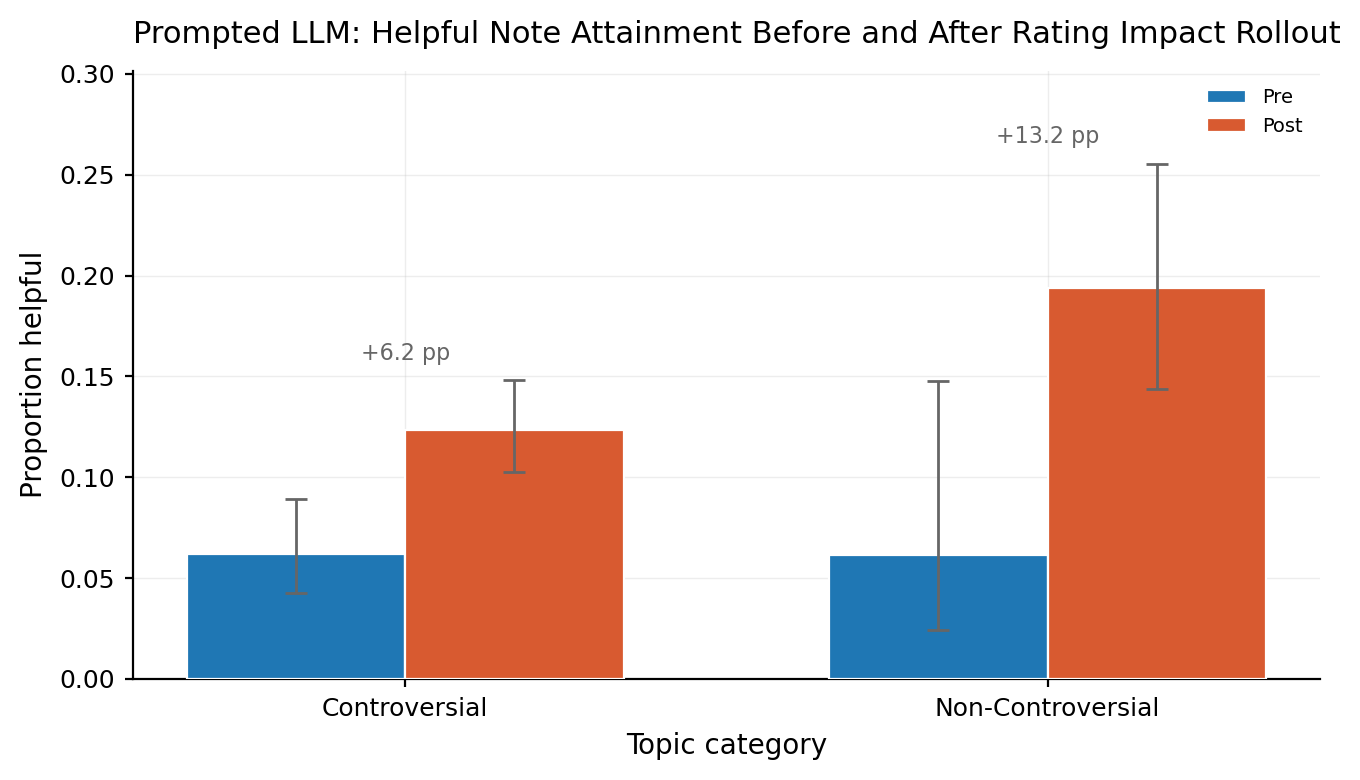

Figure saved to /accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/prompted_llm_pre_post_helpful_difference_2022-10-01.png


In [ ]:
APPENDIX_FIGURE_DIR = Path("/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix")
APPENDIX_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_WINDOW_START = "2022-06-01"
FIGURE_WINDOW_END = "2023-03-01"


def calculate_controversy_proportions_principled(
    status_history_df: pd.DataFrame,
    notes_df: pd.DataFrame,
    note_topic_col: str='noteTopic',
    time: str = "W",
    min_n: int = 30,               # hide points with fewer than min_n denominators
    smooth_window: int = 7,        # centered window length for smoothing
    jeffreys_alpha: float = 0.5,   # Jeffreys prior for shrinkage
    jeffreys_beta: float = 0.5
) -> pd.DataFrame:
    """
    Weekly proportions by topic category with:
      - category-specific denominators (unique tweets seeing their first note in that category)
      - Jeffreys-shrunk proportions to stabilize small n
      - Wilson 95% CIs
      - weighted, centered rolling smoothing (by denominator)
      - NaN where denominator < min_n (kept for plotting masks)
    """
    # Merge & prepare
    df = pd.merge(status_history_df, notes_df, on='noteId', how='right',
                  suffixes=('_status', '_note'))

    print(df.columns)
    df['note_creation_dt'] = pd.to_datetime(df['createdAtMillis_note'], unit='ms')

    df['topic_category'] = df[note_topic_col].apply(
        lambda x: 'Controversial' if x in CONTROVERSIAL_TOPICS
        else ('Non-Controversial' if x in NON_CONTROVERSIAL_TOPICS else 'Other')
    )

    out = []

    for category in df['topic_category'].dropna().unique():
        cdf = df[df['topic_category'] == category]

        # denominator: first time each tweet gets ANY note in this category
        denom_idx = cdf.groupby('tweetId')['note_creation_dt'].min()
        denom = denom_idx.value_counts().resample(time).sum().fillna(0).rename('denominator_tweets')

        # helpful / unhelpful: first time each tweet gets a note with that final status in this category
        helpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()
        unhelpful_first = cdf[cdf['currentStatus'] == 'CURRENTLY_RATED_NOT_HELPFUL'] \
                          .groupby('tweetId')['note_creation_dt'].min()

        helpful = helpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'helpful_{category}')
        unhelpful = unhelpful_first.value_counts().resample(time).sum().reindex(denom.index).fillna(0).rename(f'unhelpful_{category}')

        # raw proportions (nan where n=0)
        with np.errstate(divide='ignore', invalid='ignore'):
            p_help = np.where(denom.values > 0, helpful.values / denom.values, np.nan)
            p_unhl = np.where(denom.values > 0, unhelpful.values / denom.values, np.nan)

        # Jeffreys-shrunk estimates
        ph_shrunk = (helpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        pu_shrunk = (unhelpful.values + jeffreys_alpha) / (denom.values + jeffreys_alpha + jeffreys_beta)
        ph_shrunk = np.where(denom.values > 0, ph_shrunk, np.nan)
        pu_shrunk = np.where(denom.values > 0, pu_shrunk, np.nan)

        # Wilson CIs (on raw proportions)
        ph_lo, ph_hi = _wilson_ci(helpful.values, denom.values)
        pu_lo, pu_hi = _wilson_ci(unhelpful.values, denom.values)

        # mask tiny denominators
        mask = denom.values >= min_n
        def _mask(arr):
            arr = np.asarray(arr, dtype=float)
            arr[~mask] = np.nan
            return arr

        # smooth (weighted by denominators)
        ph_smooth = _weighted_centered_rolling(_mask(ph_shrunk), denom.values, smooth_window)
        pu_smooth = _weighted_centered_rolling(_mask(pu_shrunk), denom.values, smooth_window)

        cat_df = pd.DataFrame({
            'week_dt': denom.index,
            'denominator_tweets_' + category: denom.values,
            f'helpful_{category}': helpful.values,
            f'unhelpful_{category}': unhelpful.values,
            f'prop_helpful_raw_{category}': _mask(p_help),
            f'prop_unhelpful_raw_{category}': _mask(p_unhl),
            f'prop_helpful_shrunk_{category}': _mask(ph_shrunk),
            f'prop_unhelpful_shrunk_{category}': _mask(pu_shrunk),
            f'prop_helpful_lo_{category}': _mask(ph_lo),
            f'prop_helpful_hi_{category}': _mask(ph_hi),
            f'prop_unhelpful_lo_{category}': _mask(pu_lo),
            f'prop_unhelpful_hi_{category}': _mask(pu_hi),
            f'prop_helpful_smooth_{category}': ph_smooth.values,
            f'prop_unhelpful_smooth_{category}': pu_smooth.values,
        })
        out.append(cat_df)

    # outer-merge all categories on week_dt
    result = out[0]
    for k in out[1:]:
        result = pd.merge(result, k, on='week_dt', how='outer')

    result = result.sort_values('week_dt').reset_index(drop=True)
    return df, result


# --- utility: Wilson CI for aggregated counts ------------------------------
def wilson_ci_agg(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + (z**2) / (2*n)) / denom
    margin = (z * np.sqrt((phat*(1-phat)/n) + (z**2)/(4*n**2))) / denom
    return center - margin, center + margin


def plot_pre_post_helpful_difference(
    df_weekly: pd.DataFrame,
    cutoff_date: str = "2022-10-01",
    categories=("Controversial", "Non-Controversial"),
    period_labels=("Pre", "Post"),
    colors=None,
    title="Helpful Note Attainment Before and After Rating Impact Rollout",
    save_path=None,
):
    if colors is None:
        colors = [_C_BLUE, _C_ORANGE]

    cutoff = pd.to_datetime(cutoff_date)
    df = df_weekly.copy()
    df["week_dt"] = pd.to_datetime(df["week_dt"])
    df = df.sort_values("week_dt")
    df["period"] = np.where(df["week_dt"] < cutoff, "Pre", "Post")

    rows = []
    for cat in categories:
        dcol = f"denominator_tweets_{cat}"
        hcol = f"helpful_{cat}"
        if dcol not in df.columns or hcol not in df.columns:
            raise KeyError(f"Expected columns '{dcol}' and '{hcol}' not found in dataframe.")

        for period in period_labels:
            g = df[df["period"] == period]
            n = np.nansum(g[dcol].values)
            k = np.nansum(g[hcol].values)
            p = (k / n) if n > 0 else np.nan
            lo, hi = wilson_ci_agg(k, n)
            rows.append({
                "category": cat,
                "period": period,
                "k_helpful": k,
                "n_den": n,
                "prop_helpful": p,
                "ci_lo": lo,
                "ci_hi": hi,
            })

    agg = pd.DataFrame(rows)

    print("\nSummary of mean helpfulness and 95% CI (Wilson):")
    for cat in categories:
        for period in period_labels:
            row = agg[(agg["category"] == cat) & (agg["period"] == period)]
            if not row.empty:
                p = row["prop_helpful"].values[0]
                lo = row["ci_lo"].values[0]
                hi = row["ci_hi"].values[0]
                print(f"{cat:>15} | {period:>4} | mean = {p:.3f}, 95% CI = [{lo:.3f}, {hi:.3f}]")

    apply_publication_style()
    fig, axes = plt.subplots(1, len(categories), figsize=(4.2 * len(categories), 4.0), sharey=True)
    if len(categories) == 1:
        axes = [axes]

    ymax = agg["ci_hi"].max()
    if pd.isna(ymax):
        ymax = agg["prop_helpful"].max()
    ymax = min(1.0, ymax * 1.18)

    for ax, cat in zip(axes, categories):
        sub = agg[agg["category"] == cat].set_index("period").loc[list(period_labels)]
        x = np.arange(len(period_labels))
        y = sub["prop_helpful"].to_numpy(dtype=float)
        yerr = np.vstack([
            y - sub["ci_lo"].to_numpy(dtype=float),
            sub["ci_hi"].to_numpy(dtype=float) - y,
        ])

        ax.bar(
            x,
            y,
            width=0.68,
            color=colors[:len(period_labels)],
            edgecolor="white",
            linewidth=0.8,
            yerr=yerr,
            error_kw=dict(ecolor=_C_ZERO, lw=1.0, capsize=4, capthick=1.0),
            zorder=3,
        )

        for xi, prop, ci_hi in zip(x, y, sub["ci_hi"]):
            ax.text(
                xi,
                ci_hi + ymax * 0.025,
                f"{prop:.1%}",
                ha="center",
                va="bottom",
                fontsize=_FONT_ANNOT,
                color=_C_ZERO,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(period_labels, fontsize=_FONT_TICK)
        ax.set_xlabel(cat, fontsize=_FONT_LABEL, labelpad=10)
        ax.set_ylim(0, ymax)
        _setup_ax(ax)

    axes[0].set_ylabel("Proportion of Tweets With at Least One Helpful Note", fontsize=_FONT_LABEL)
    _finalize(fig, axes, title=title)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    plt.show()


# Intersection-set comparison: keep only notes that all three topic modelers classify
# into the controversial/non-controversial topic lists.
notes_topic_intersection = notes_bow_topic.merge(
    notes_llm_topic,
    left_on='noteId',
    right_on='NOTEID',
    how='inner',
).copy()

notes_topic_intersection['noteTopic'] = notes_topic_intersection['noteTopic'].astype('string').str.strip()
notes_topic_intersection['TOPIC'] = notes_topic_intersection['TOPIC'].astype('string').str.strip().str.replace(' ', '', regex=False)
notes_topic_intersection['LLAMA4'] = notes_topic_intersection['LLAMA4'].astype('string').str.strip().str.replace(' ', '', regex=False)

valid_topic_labels = set(CONTROVERSIAL_TOPICS) | set(NON_CONTROVERSIAL_TOPICS)
for topic_col in ['noteTopic', 'TOPIC', 'LLAMA4']:
    notes_topic_intersection[f'{topic_col}_controversy'] = np.select(
        [
            notes_topic_intersection[topic_col].isin(CONTROVERSIAL_TOPICS),
            notes_topic_intersection[topic_col].isin(NON_CONTROVERSIAL_TOPICS),
        ],
        ['Controversial', 'Non-Controversial'],
        default=pd.NA,
    )

intersection_before = len(notes_topic_intersection)
notes_topic_intersection = notes_topic_intersection.dropna(
    subset=['noteTopic_controversy', 'TOPIC_controversy', 'LLAMA4_controversy']
).copy()

print(f'Intersection notes with all three valid classifications: {len(notes_topic_intersection):,} / {intersection_before:,}')
print(notes_topic_intersection[['noteTopic_controversy', 'TOPIC_controversy', 'LLAMA4_controversy']].value_counts(dropna=False))

history_df["noteId"] = history_df["noteId"].astype(int)
notes_topic_intersection["noteId"] = notes_topic_intersection["noteId"].astype(int)

l_df_prompted_llm, p_df_prompted_llm = calculate_controversy_proportions_principled(
    history_df,
    notes_topic_intersection,
    note_topic_col="TOPIC",
    time="W",
    min_n=6,
    smooth_window=9,
)

plot_pre_post_helpful_difference(
    p_df_prompted_llm[
        (p_df_prompted_llm["week_dt"] < FIGURE_WINDOW_END)
        & (p_df_prompted_llm["week_dt"] > FIGURE_WINDOW_START)
    ],
    cutoff_date="2022-10-01",
    title="Prompted LLM: Helpful Note Attainment Before and After Rating Impact Rollout",
    save_path=APPENDIX_FIGURE_DIR / "prompted_llm_pre_post_helpful_difference_2022-10-01.png",
)


# Appendix Figure 15

Index(['noteId', 'noteAuthorParticipantId_status', 'createdAtMillis_status',
       'timestampMillisOfFirstNonNMRStatus', 'firstNonNMRStatus',
       'timestampMillisOfCurrentStatus', 'currentStatus',
       'timestampMillisOfLatestNonNMRStatus', 'mostRecentNonNMRStatus',
       'timestampMillisOfStatusLock', 'lockedStatus',
       'timestampMillisOfRetroLock', 'currentCoreStatus',
       'currentExpansionStatus', 'currentGroupStatus', 'currentDecidedBy',
       'currentModelingGroup', 'timestampMillisOfMostRecentStatusChange',
       'timestampMillisOfNmrDueToMinStableCrhTime', 'currentMultiGroupStatus',
       'currentModelingMultiGroup', 'timestampMinuteOfFinalScoringOutput',
       'timestampMillisOfFirstNmrDueToMinStableCrhTime',
       'noteAuthorParticipantId_note', 'createdAtMillis_note', 'tweetId',
       'classification', 'believable', 'harmful', 'validationDifficulty',
       'misleadingOther', 'misleadingFactualError',
       'misleadingManipulatedMedia', 'misleadingOutdate

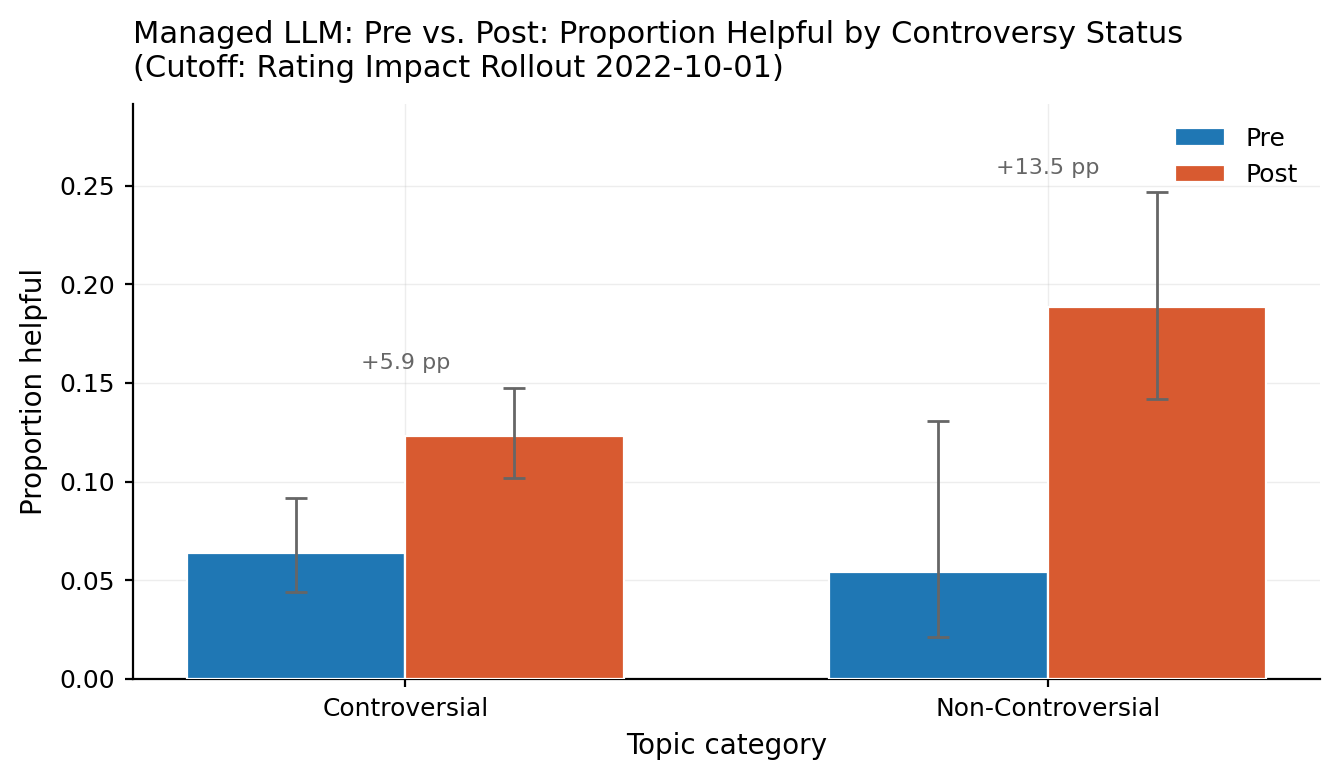

Figure saved to /accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/managed_llm_pre_post_helpful_difference_2022-10-01.png


In [90]:
l_df_managed_llm, p_df_managed_llm = calculate_controversy_proportions_principled(
    history_df,
    notes_topic_intersection,
    note_topic_col="LLAMA4",
    time="W",
    min_n=6,
    smooth_window=9,
)

plot_pre_post_helpful_difference(
    p_df_managed_llm[
        (p_df_managed_llm["week_dt"] < FIGURE_WINDOW_END)
        & (p_df_managed_llm["week_dt"] > FIGURE_WINDOW_START)
    ],
    cutoff_date="2022-10-01",
    title="Managed LLM: Helpful Note Attainment Before and After Rating Impact Rollout",
    save_path=APPENDIX_FIGURE_DIR / "managed_llm_pre_post_helpful_difference_2022-10-01.png",
)


# Appendix Figure 16


Summary of mean helpfulness and 95% CI (Wilson):
  Controversial |  Pre | mean = 0.143, 95% CI = [0.071, 0.267]
  Controversial | Post | mean = 0.080, 95% CI = [0.059, 0.107]
Non-Controversial |  Pre | mean = 0.131, 95% CI = [0.068, 0.238]
Non-Controversial | Post | mean = 0.265, 95% CI = [0.232, 0.302]


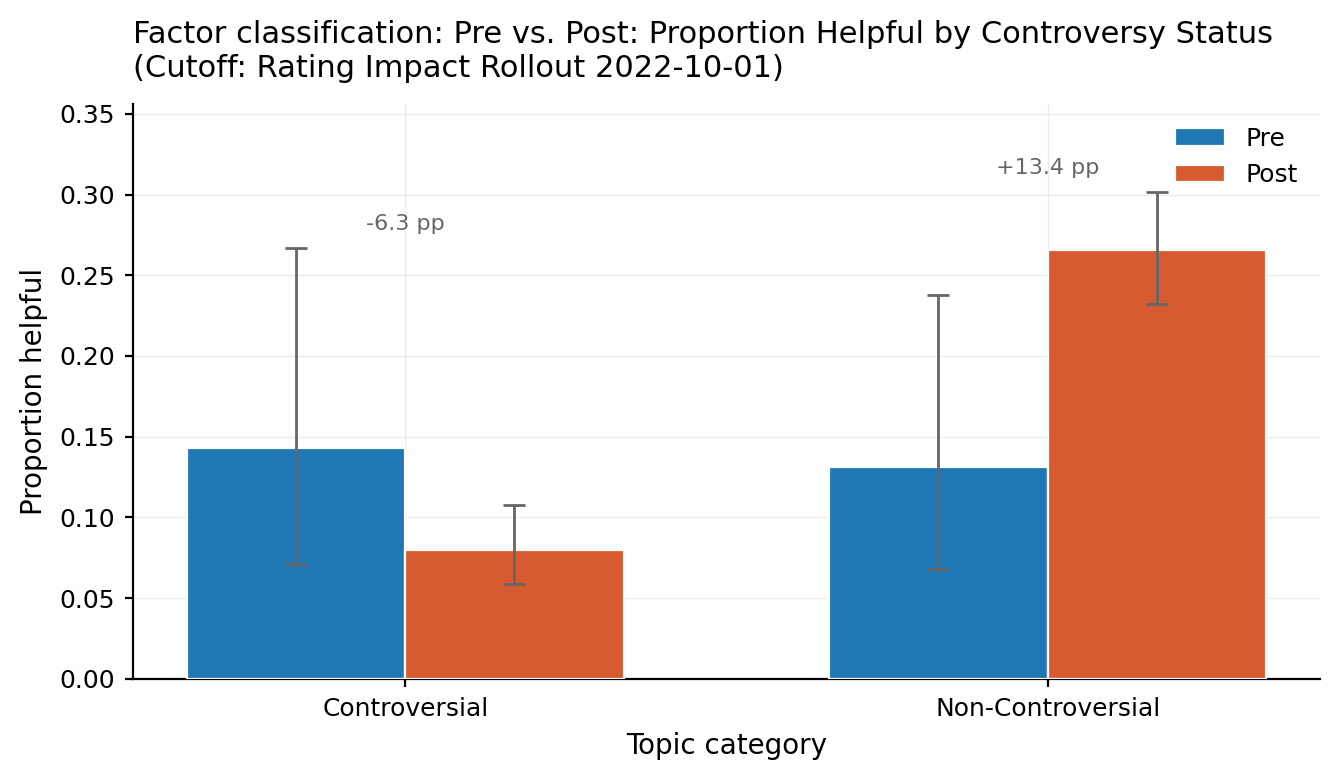

Figure saved to /accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/factor_classification_pre_post_helpful_difference_2022-10-01.png


In [91]:
plot_pre_post_helpful_difference(
    p_df[
        (p_df["week_dt"] < FIGURE_WINDOW_END)
        & (p_df["week_dt"] > FIGURE_WINDOW_START)
    ],
    cutoff_date="2022-10-01",
    title="Factor Classification: Helpful Note Attainment Before and After Rating Impact Rollout",
    save_path=APPENDIX_FIGURE_DIR / "factor_classification_pre_post_helpful_difference_2022-10-01.png",
)


# Extra DiD Plot

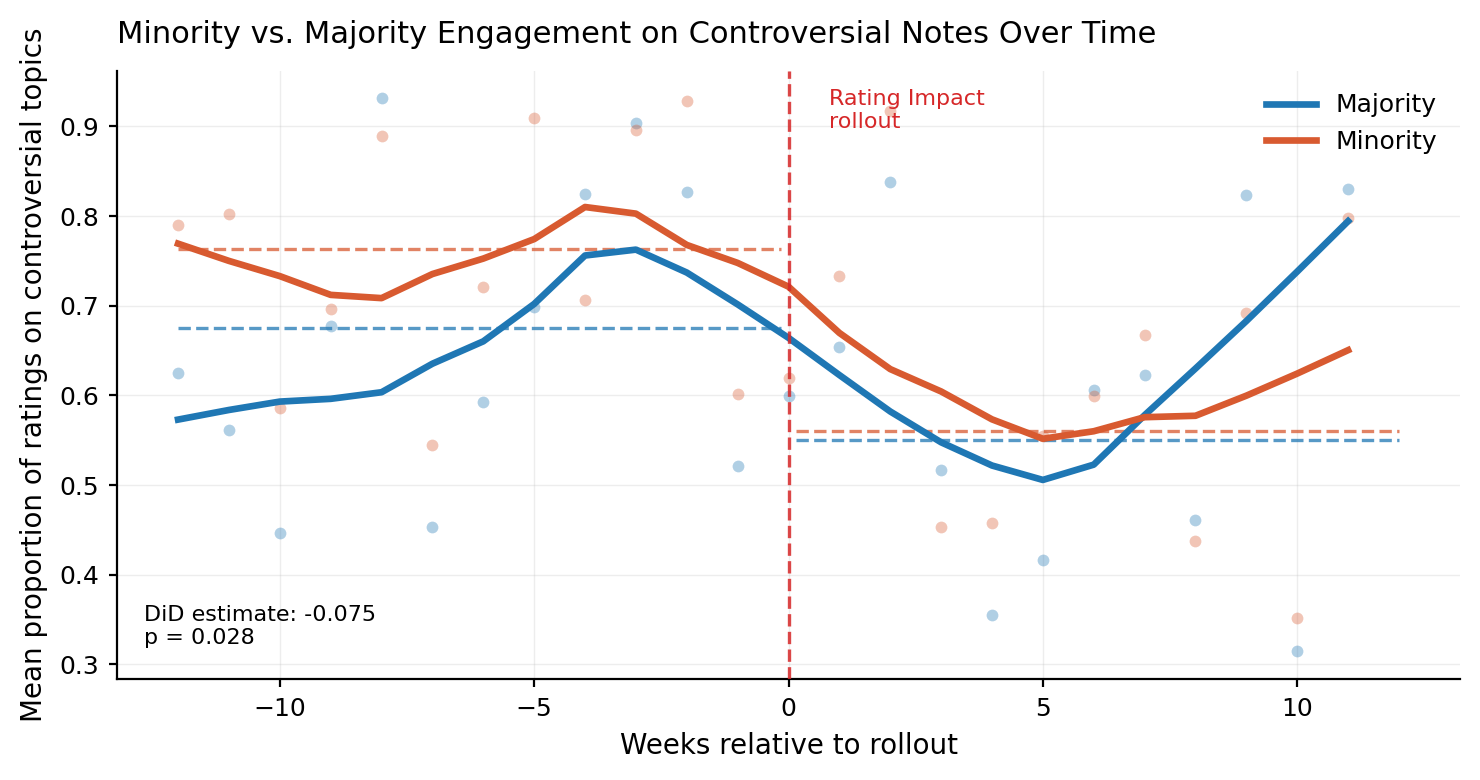

In [94]:
def plot_did_smoothed_trends(
    df,
    res,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=12,
    frac_lowess=0.35,
    title="DiD: controversial engagement",
    save_path=None,
):
    cutoff = pd.to_datetime(cutoff_date)

    d = df.copy()
    d["week_dt"] = pd.to_datetime(d["week_dt"])
    d = d[d[minority_col].notna()].copy()

    d = d[
        (d["week_dt"] >= cutoff - pd.Timedelta(weeks=window_weeks)) &
        (d["week_dt"] < cutoff + pd.Timedelta(weeks=window_weeks))
    ].copy()

    d["Post"] = (d["week_dt"] >= cutoff).astype(int)
    d["group"] = np.where(d[minority_col].eq(1), "Minority", "Majority")
    d["rel_week"] = ((d["week_dt"] - cutoff).dt.days / 7).round().astype(int)

    weekly = (
        d.groupby(["rel_week", "group"], as_index=False)[outcome]
        .mean()
    )

    did_means = (
        d.groupby(["group", "Post"], as_index=False)[outcome]
        .mean()
    )

    colors = {
        "Majority": _C_BLUE,
        "Minority": _C_ORANGE,
    }

    apply_publication_style()
    fig, ax = plt.subplots(figsize=(7.5, 4.0))

    for group in ["Majority", "Minority"]:
        sub = weekly[weekly["group"].eq(group)].sort_values("rel_week")
        x = sub["rel_week"].to_numpy(dtype=float)
        y = sub[outcome].to_numpy(dtype=float)

        ax.scatter(
            x, y,
            color=colors[group],
            alpha=0.35,
            s=18,
            linewidths=0,
            zorder=2,
        )

        if len(sub) >= 4:
            sm = _lowess(y, x, frac=frac_lowess, return_sorted=True)
            ax.plot(
                sm[:, 0], sm[:, 1],
                color=colors[group],
                linewidth=2.4,
                label=group,
                zorder=4,
            )

        gmeans = did_means[did_means["group"].eq(group)]

        pre_mean = gmeans.loc[gmeans["Post"].eq(0), outcome].iloc[0]
        post_mean = gmeans.loc[gmeans["Post"].eq(1), outcome].iloc[0]

        ax.hlines(
            pre_mean,
            xmin=-window_weeks,
            xmax=-0.15,
            color=colors[group],
            linewidth=1.2,
            linestyle="--",
            alpha=0.75,
            zorder=3,
        )

        ax.hlines(
            post_mean,
            xmin=0.15,
            xmax=window_weeks,
            color=colors[group],
            linewidth=1.2,
            linestyle="--",
            alpha=0.75,
            zorder=3,
        )

    did_coef = res.params["treat"]
    did_pval = res.pvalues["treat"]

    ax.axvline(
        0,
        color=_C_EVENT,
        linewidth=1.2,
        linestyle="--",
        alpha=0.85,
        zorder=5,
    )

    ax.text(
        0.8,
        0.97,
        "Rating Impact\nrollout",
        color=_C_EVENT,
        fontsize=_FONT_ANNOT,
        va="top",
        ha="left",
        transform=ax.get_xaxis_transform(),
    )

    ax.text(
        0.02,
        0.05,
        f"DiD estimate: {did_coef:.3f}\np = {did_pval:.3f}",
        transform=ax.transAxes,
        fontsize=_FONT_ANNOT,
        ha="left",
        va="bottom",
    )

    ax.legend(frameon=False, fontsize=_FONT_LEGEND, loc="upper right")

    _setup_ax(ax)
    _finalize(
        fig,
        ax,
        xlabel="Weeks relative to rollout",
        ylabel="Mean proportion of ratings on controversial topics",
        title=title,
        save_path=save_path,
    )

    return weekly, did_means


weekly, did_means = plot_did_smoothed_trends(
    out,
    res1,
    outcome="prop_controversial",
    minority_col="minority",
    cutoff_date=partial_rollout_date,
    window_weeks=12,
    title="Minority vs. Majority Engagement on Controversial Notes Over Time",
    save_path="/accounts/projects/jchayes/commnotes/commnotes-analysis/figures/appendix/did_smoothed_prop_controversial.png",
)
